# 1. Business Understanding

## 1.1 Business Context

Customer churn is a major business challenge for subscription-based telecommunications companies. Losing existing customers can reduce recurring revenue and increase the need for customer acquisition efforts.

The company wants to identify customers who are at higher risk of leaving so that the retention team can intervene before the customer churns.

However, the retention team has limited resources. Therefore, the objective is not simply to identify every possible churner, but to prioritize customers for whom retention intervention is most valuable.

---

## 1.2 Business Problem

The business needs a system that can identify customers who are likely to churn and help the retention team prioritize their limited resources toward high-risk customers.

The key business question is:

> **Which customers are most likely to churn, and which customers should the business prioritize for retention efforts?**

---

## 1.3 Machine Learning Problem

This business problem can be formulated as a supervised binary classification problem.

**Input:** Customer information and behaviour available at prediction time.

**Output:** The probability that a customer will churn.

The model's probability output will subsequently be converted into risk levels and used to prioritize potential retention actions.

---

## 1.4 Prediction Objective

The objective of the model is:

> **Estimate the probability that an existing customer will churn based only on information that would realistically be available when the prediction is made.**

This prediction should be useful for proactive retention rather than explaining a churn event after it has already occurred.

---

## 1.5 Business Decision Framework

The model will not be treated as an isolated prediction system.

The intended workflow is:

Customer Information
↓
Churn Probability
↓
Risk Level
↓
Customer Priority
↓
Retention Intervention

The final system should therefore support business decision-making rather than simply outputting a binary churn prediction.

---

## 1.6 Cost of Prediction Errors

The two major prediction errors have different business implications.

### False Negative

A customer who actually churns is predicted as a non-churner.

Potential consequence:

* The customer may not receive a retention intervention.
* The business may lose the customer and associated future revenue.

### False Positive

A customer who is unlikely to churn is incorrectly identified as high risk.

Potential consequence:

* Retention resources may be spent unnecessarily.
* The business may provide discounts or incentives to customers who would have remained anyway.

Therefore, the project will not rely primarily on accuracy. The relative business cost of false positives and false negatives will be considered when selecting evaluation metrics and the final prediction threshold.

---

## 1.7 Success Criteria

### Machine Learning Success

The model should:

* Generalize reliably to unseen customers.
* Demonstrate strong and stable classification performance.
* Handle class imbalance appropriately.
* Produce useful probability estimates for customer risk prioritization.
* Avoid data leakage.
* Maintain a reproducible preprocessing and prediction pipeline.

### Business Success

The model should:

* Help identify customers at higher risk of churn.
* Support prioritization of limited retention resources.
* Provide interpretable insights into factors associated with churn.
* Translate predictions into meaningful business risk categories.
* Support a practical retention decision process.

---

## 1.8 Project Scope

This project will cover the complete machine learning lifecycle:

**Business Understanding → Data Understanding → EDA → Data Preparation → Leakage Investigation → Model Development → Validation → Evaluation → Threshold Optimization → Error Analysis → Interpretability → Business Prioritization → Deployment**

The final model will be integrated into a reproducible prediction pipeline and deployed through a Streamlit application.

---

## 1.9 Key Principle

> **The goal is not to build the model with the highest single metric. The goal is to build the most reliable and practically useful churn prediction system for the defined business objective.**


# 2. Dataset Understanding

## 2.1 Dataset Overview

The dataset used in this project is the IBM Telco Customer Churn dataset.

It contains customer-level information from a telecommunications company, including demographic characteristics, subscribed services, contract information, payment details, tenure, and customer churn status.

The purpose of this stage is to understand the structure, meaning, and quality of the available data before performing any data cleaning or transformation.

### Objectives

In this stage, we will:

* Inspect the dataset dimensions.
* Understand the meaning and data type of each feature.
* Identify numerical and categorical variables.
* Examine the target variable.
* Investigate feature cardinality.
* Identify missing or suspicious values.
* Check for duplicate records.
* Identify potentially irrelevant or leakage-prone variables.

> **Important:** No data cleaning or feature transformation will be performed before the initial dataset audit is complete.


### 2.2  Import Necessary libraries & dataset : 

In [4]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.api.types import is_numeric_dtype

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score,precision_score,recall_score,f1_score,roc_curve

In [2]:
telco_data = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
telco_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 2.3 Performing initial analysis :

In [3]:
telco_data.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [4]:
telco_data.sample(5, random_state=42)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
185,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,24.80,24.8,Yes
2715,0484-JPBRU,Male,0,No,No,41,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,No
3825,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1031.7,No
1807,6910-HADCM,Female,0,No,No,1,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35,Yes
132,8587-XYZSF,Male,0,No,No,67,Yes,No,DSL,No,...,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.1,No


In [5]:
telco_data.shape

(7043, 21)

### Initial Observation

The dataset contains 7,043 customer records and 21 variables.

Each row represents a customer, while the columns contain information describing the customer's demographic characteristics, subscribed services, account information, billing details, and churn status.

At this stage, the dataset dimensions are consistent with the expected IBM Telco Customer Churn dataset. Further inspection is required before making any assumptions about data quality or feature suitability.


In [6]:
telco_data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
telco_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### 2.4 Feature Dictionary :



| Feature            | Description                                               | Initial Type | Role       |
| ------------------ | --------------------------------------------------------- | ------------ | ---------- |
| `customerID`       | Unique customer identifier                                | Categorical  | Identifier |
| `gender`           | Customer gender                                           | Categorical  | Feature    |
| `SeniorCitizen`    | Whether the customer is a senior citizen                  | Binary       | Feature    |
| `Partner`          | Whether the customer has a partner                        | Binary       | Feature    |
| `Dependents`       | Whether the customer has dependents                       | Binary       | Feature    |
| `tenure`           | Number of months the customer has stayed with the company | Numerical    | Feature    |
| `PhoneService`     | Whether the customer has phone service                    | Binary       | Feature    |
| `MultipleLines`    | Multiple phone lines subscription status                  | Categorical  | Feature    |
| `InternetService`  | Type of internet service                                  | Categorical  | Feature    |
| `OnlineSecurity`   | Online security subscription status                       | Categorical  | Feature    |
| `OnlineBackup`     | Online backup subscription status                         | Categorical  | Feature    |
| `DeviceProtection` | Device protection subscription status                     | Categorical  | Feature    |
| `TechSupport`      | Technical support subscription status                     | Categorical  | Feature    |
| `StreamingTV`      | Streaming TV subscription status                          | Categorical  | Feature    |
| `StreamingMovies`  | Streaming movies subscription status                      | Categorical  | Feature    |
| `Contract`         | Customer contract type                                    | Categorical  | Feature    |
| `PaperlessBilling` | Whether paperless billing is enabled                      | Binary       | Feature    |
| `PaymentMethod`    | Customer payment method                                   | Categorical  | Feature    |
| `MonthlyCharges`   | Customer's monthly charges                                | Numerical    | Feature    |
| `TotalCharges`     | Total charges accumulated by the customer                 | Numerical*   | Feature    |
| `Churn`            | Whether the customer churned                              | Binary       | Target     |

* `TotalCharges` will be investigated further because its stored data type may require attention.


### 2.5 Identifying the target :

In [8]:
telco_data["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
telco_data["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

The target variable for this project is `Churn`.

It represents whether a customer churned:

* `Yes` → Customer churned
* `No` → Customer did not churn

The target distribution will be examined in detail during the EDA and class-imbalance analysis stages.

At this stage, the target appears to contain two classes, confirming that the problem can be formulated as a binary classification task.


#### Initial Dataset Observations

The dataset contains 7,043 customer records and 21 columns.

The dataset consists primarily of categorical variables, with 18 columns stored as `object`, two integer columns, and one floating-point column.

An initial data-type inspection revealed that `TotalCharges` is stored as an `object` despite representing a numerical monetary value. This requires further investigation before any type conversion or cleaning is performed.

Although all columns report 7,043 non-null observations, this does not confirm that the dataset contains no missing or invalid values. Blank strings or placeholder values may still be present and will therefore be investigated separately.

The target variable `Churn` contains two classes:

- No: 5,174 customers (73.46%)
- Yes: 1,869 customers (26.54%)

The target is therefore moderately imbalanced, with churn representing approximately 26.5% of the observations. Accuracy alone will not be sufficient for evaluating the eventual classification models.

### 2.6 Feature level audit :

In [10]:
for col in telco_data.select_dtypes(include="object").columns:
    print(f"\n--- {col} ---")
    print(telco_data[col].unique())


--- customerID ---
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

--- gender ---
['Female' 'Male']

--- Partner ---
['Yes' 'No']

--- Dependents ---
['No' 'Yes']

--- PhoneService ---
['No' 'Yes']

--- MultipleLines ---
['No phone service' 'No' 'Yes']

--- InternetService ---
['DSL' 'Fiber optic' 'No']

--- OnlineSecurity ---
['No' 'Yes' 'No internet service']

--- OnlineBackup ---
['Yes' 'No' 'No internet service']

--- DeviceProtection ---
['No' 'Yes' 'No internet service']

--- TechSupport ---
['No' 'Yes' 'No internet service']

--- StreamingTV ---
['No' 'Yes' 'No internet service']

--- StreamingMovies ---
['No' 'Yes' 'No internet service']

--- Contract ---
['Month-to-month' 'One year' 'Two year']

--- PaperlessBilling ---
['Yes' 'No']

--- PaymentMethod ---
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

--- TotalCharges ---
['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']

--- Churn ---


In [11]:
telco_data.nunique().sort_values()

Churn                  2
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
PaperlessBilling       2
PhoneService           2
Contract               3
StreamingMovies        3
StreamingTV            3
TechSupport            3
OnlineBackup           3
OnlineSecurity         3
InternetService        3
MultipleLines          3
DeviceProtection       3
PaymentMethod          4
tenure                73
MonthlyCharges      1585
TotalCharges        6531
customerID          7043
dtype: int64

In [12]:
telco_data.isnull().sum().sort_values(ascending=False)

customerID          0
DeviceProtection    0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
PaperlessBilling    0
Contract            0
StreamingMovies     0
StreamingTV         0
TechSupport         0
OnlineBackup        0
gender              0
OnlineSecurity      0
InternetService     0
MultipleLines       0
PhoneService        0
tenure              0
Dependents          0
Partner             0
SeniorCitizen       0
Churn               0
dtype: int64

#### To investigate whether "No internet service " & "no" are conveying same meaning or not :

In [13]:
telco_data.groupby("InternetService")["OnlineSecurity"].value_counts()

InternetService  OnlineSecurity     
DSL              No                     1241
                 Yes                    1180
Fiber optic      No                     2257
                 Yes                     839
No               No internet service    1526
Name: count, dtype: int64

In [14]:
service_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

for col in service_cols:
    print(f"\n--- {col} ---")
    print(pd.crosstab(telco_data["InternetService"], telco_data[col]))


--- OnlineSecurity ---
OnlineSecurity     No  No internet service   Yes
InternetService                                 
DSL              1241                    0  1180
Fiber optic      2257                    0   839
No                  0                 1526     0

--- OnlineBackup ---
OnlineBackup       No  No internet service   Yes
InternetService                                 
DSL              1335                    0  1086
Fiber optic      1753                    0  1343
No                  0                 1526     0

--- DeviceProtection ---
DeviceProtection    No  No internet service   Yes
InternetService                                  
DSL               1356                    0  1065
Fiber optic       1739                    0  1357
No                   0                 1526     0

--- TechSupport ---
TechSupport        No  No internet service   Yes
InternetService                                 
DSL              1243                    0  1178
Fiber optic      223

#### 2.6.1 Inspect suspicious values :

In [15]:
telco_data["TotalCharges"].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [16]:
total_charges_numeric = pd.to_numeric(
    telco_data["TotalCharges"],
    errors="coerce"
)

telco_data[
    total_charges_numeric.isna()
]["TotalCharges"].value_counts()

TotalCharges
    11
Name: count, dtype: int64

In [17]:
telco_data[
    total_charges_numeric.isna()
]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [18]:
telco_data[
    total_charges_numeric.isna()
][["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


#### Observation: `TotalCharges` Data-Type Anomaly

The `TotalCharges` column is stored as an object despite representing a numerical monetary value.

Converting the column using `pd.to_numeric(..., errors="coerce")` identified 11 non-numeric values. Inspection of these records shows that all 11 correspond to customers with:

- `tenure = 0`
- valid positive `MonthlyCharges`
- blank `TotalCharges`
- `Churn = No`

This suggests that the blank values are associated with newly recorded customers for whom cumulative charges have not yet been recorded.

The issue will be handled during the data-cleaning stage rather than modifying the raw dataset during the initial audit. 

##### Actual raw representation :

In [19]:
telco_data.loc[
    total_charges_numeric.isna(),
    "TotalCharges"
].apply(repr)

488     ' '
753     ' '
936     ' '
1082    ' '
1340    ' '
3331    ' '
3826    ' '
4380    ' '
5218    ' '
6670    ' '
6754    ' '
Name: TotalCharges, dtype: object

#### Observation: Whitespace Values in `TotalCharges`

Further inspection using `repr()` confirmed that the 11 non-numeric values in `TotalCharges` are whitespace strings (`'  '`).

Therefore, these are not valid numerical values and should be treated as missing during the data-cleaning stage.

All 11 affected customers have `tenure = 0`, which is consistent with the possibility that these are newly recorded customers without accumulated total charges.

The raw dataset will remain unchanged until the dedicated data-cleaning stage.

#### Checking duplicate :

In [20]:
telco_data.duplicated().sum()

0

In [21]:
telco_data["customerID"].duplicated().sum()

0

#### Observation: Duplicate and Identifier Integrity

Two separate duplication checks were performed.

- Complete duplicate rows: **0**
- Duplicate `customerID` values: **0**

Therefore, the dataset contains no completely duplicated records, and each customer is represented by a unique `customerID`.

This confirms that there is no immediate row-level duplication issue requiring removal or deduplication.

#### Investigate Feature Cardinality :

In [22]:
for col in telco_data.columns:
    print(
        f"{col:20} | "
        f"Unique: {telco_data[col].nunique():4} | "
        f"Type: {telco_data[col].dtype}"
    )

customerID           | Unique: 7043 | Type: object
gender               | Unique:    2 | Type: object
SeniorCitizen        | Unique:    2 | Type: int64
Partner              | Unique:    2 | Type: object
Dependents           | Unique:    2 | Type: object
tenure               | Unique:   73 | Type: int64
PhoneService         | Unique:    2 | Type: object
MultipleLines        | Unique:    3 | Type: object
InternetService      | Unique:    3 | Type: object
OnlineSecurity       | Unique:    3 | Type: object
OnlineBackup         | Unique:    3 | Type: object
DeviceProtection     | Unique:    3 | Type: object
TechSupport          | Unique:    3 | Type: object
StreamingTV          | Unique:    3 | Type: object
StreamingMovies      | Unique:    3 | Type: object
Contract             | Unique:    3 | Type: object
PaperlessBilling     | Unique:    2 | Type: object
PaymentMethod        | Unique:    4 | Type: object
MonthlyCharges       | Unique: 1585 | Type: float64
TotalCharges         | Unique: 6

#### Observation: Feature Cardinality and Semantic Roles

The cardinality analysis shows that the dataset contains a mixture of binary categorical, multi-category categorical, numerical, identifier, and target variables.

`customerID` has 7,043 unique values, equal to the number of records, confirming that it functions as a unique identifier rather than a behavioural feature.

Several features have low cardinality, including binary variables such as `Partner`, `Dependents`, and `PaperlessBilling`, as well as multi-category variables such as `Contract`, `InternetService`, and `PaymentMethod`.

`tenure`, `MonthlyCharges`, and `TotalCharges` are conceptually numerical variables despite having different numbers of unique values. In particular, `TotalCharges` is currently stored as an object because of the whitespace values identified earlier.

Cardinality will be considered when designing the preprocessing strategy, but feature treatment will ultimately be determined by the semantic meaning of each variable rather than cardinality alone.

#### Checking Constant/Zero-Variance Features :

In [23]:
telco_data.nunique()[telco_data.nunique() == 1]

Series([], dtype: int64)

##### Observation: Constant Features

A constant-feature check was performed by identifying variables with only one unique value.

No constant features were found in the dataset.

Therefore, all available features contain at least some variation and none can be excluded solely because of zero variance at this stage.

#### Data Quality: Range & Validity Checks :

In [24]:
telco_data[["tenure", "MonthlyCharges"]].describe()

,tenure,MonthlyCharges
count,7043.000000,7043.000000
mean,32.371149,64.761692
std,24.559481,30.090047
min,0.000000,18.250000
25%,9.000000,35.500000
50%,29.000000,70.350000
75%,55.000000,89.850000
max,72.000000,118.750000


In [25]:
telco_data["SeniorCitizen"].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

In [26]:
telco_data[["tenure", "MonthlyCharges"]].min()

tenure             0.00
MonthlyCharges    18.25
dtype: float64

### 2.7 - Categorical Data Quality Audit :

#### Get a clean category summary :

In [27]:
categorical_cols = telco_data.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(telco_data[col].value_counts(dropna=False))


--- customerID ---
customerID
7590-VHVEG    1
3791-LGQCY    1
6008-NAIXK    1
5956-YHHRX    1
5365-LLFYV    1
             ..
9796-MVYXX    1
2637-FKFSY    1
1552-AAGRX    1
4304-TSPVK    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64

--- gender ---
gender
Male      3555
Female    3488
Name: count, dtype: int64

--- Partner ---
Partner
No     3641
Yes    3402
Name: count, dtype: int64

--- Dependents ---
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

--- PhoneService ---
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

--- MultipleLines ---
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

--- InternetService ---
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

--- OnlineSecurity ---
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

--- OnlineBackup -

#### Specifically check whitespace :

In [28]:
for col in categorical_cols:
    whitespace_count = telco_data[col].astype(str).str.strip().eq("").sum()
    if whitespace_count > 0:
        print(f"{col}: {whitespace_count} whitespace values")

TotalCharges: 11 whitespace values


#### Check for leading/trailing spaces in categories :

In [29]:
for col in categorical_cols:
    stripped = telco_data[col].astype(str).str.strip()
    
    if not telco_data[col].astype(str).equals(stripped):
        print(f"{col}: contains leading/trailing whitespace")

TotalCharges: contains leading/trailing whitespace


### 2.8 Feature Roles & Leakage Pre-Screen :

##### Feature Role Classification :

Based on the initial dataset audit, the variables can be classified according to their semantic role rather than their Pandas data type.

| Feature | Semantic Type | Initial Role | Notes |
|---|---|---|---|
| customerID | Identifier | Identifier | Unique customer identifier; not a predictive feature |
| gender | Categorical | Feature | Binary categorical variable |
| SeniorCitizen | Binary | Feature | Stored as 0/1 but represents a categorical state |
| Partner | Categorical | Feature | Binary categorical variable |
| Dependents | Categorical | Feature | Binary categorical variable |
| tenure | Numerical | Feature | Customer tenure in months |
| PhoneService | Categorical | Feature | Binary categorical variable |
| MultipleLines | Categorical | Feature | Phone service configuration |
| InternetService | Categorical | Feature | Type of internet service |
| OnlineSecurity | Categorical | Feature | Internet security subscription |
| OnlineBackup | Categorical | Feature | Online backup subscription |
| DeviceProtection | Categorical | Feature | Device protection subscription |
| TechSupport | Categorical | Feature | Technical support subscription |
| StreamingTV | Categorical | Feature | Streaming TV subscription |
| StreamingMovies | Categorical | Feature | Streaming movies subscription |
| Contract | Categorical | Feature | Contract type |
| PaperlessBilling | Categorical | Feature | Billing preference |
| PaymentMethod | Categorical | Feature | Payment method |
| MonthlyCharges | Numerical | Feature | Current monthly charges |
| TotalCharges | Numerical | Feature | Accumulated charges; currently requires cleaning |
| Churn | Binary categorical | Target | Outcome to be predicted |

In [30]:
telco_data.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [31]:
telco_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 3. Data Quality Assessment & Cleaning :

The initial dataset audit identified several data-quality considerations. Before modifying the dataset, each issue is evaluated based on its meaning and potential impact on the machine learning pipeline.

The raw dataset will be preserved, and all cleaning operations will be performed on a working copy.

## 3.1 Data Quality Findings

| Issue | Finding | Decision |
|---|---|---|
| Duplicate rows | No duplicate rows found | No action required |
| Duplicate customer IDs | No duplicate IDs found | No action required |
| Constant features | No constant features found | No action required |
| Missing values | No Pandas-recognized missing values initially detected | Investigated separately for hidden/whitespace values |
| `TotalCharges` data type | Stored as `object` despite representing a numerical quantity | Convert to numerical after handling whitespace |
| `TotalCharges` whitespace | 11 whitespace-only values identified | Treat as missing values |
| `TotalCharges` affected customers | All 11 have `tenure = 0` | Investigate and apply justified treatment |
| Categorical whitespace | No whitespace issues found in other categorical variables | No action required |
| Unexpected categories | No obvious invalid categories identified | No action required |
| Identifier | `customerID` is unique for every customer | Retain for identification, exclude from model features |
| Target | `Churn` contains two classes | Retain as target variable |

## 3.2 Cleaning Principles

The following principles will be followed:

1. The original raw dataset will not be modified.
2. Cleaning decisions will be based on evidence rather than assumptions.
3. Meaningful categorical states such as `No internet service` will not be treated as missing values.
4. Transformations that learn parameters from the data will eventually be fitted only on the training data.
5. The preprocessing process should be reproducible and suitable for deployment.
6. No cleaning step will be performed solely to improve model performance without a data-quality or business justification.

## 3.3 Handling TotalCharges :

In [32]:
telco_clean = telco_data.copy()

In [33]:
telco_clean["TotalCharges"] = (
    telco_clean["TotalCharges"]
    .replace(r"^\s*$", pd.NA, regex=True)
)

In [34]:
telco_clean["TotalCharges"] = pd.to_numeric(
    telco_clean["TotalCharges"],
    errors="coerce"
)

In [35]:
telco_clean["TotalCharges"].dtype

dtype('float64')

In [36]:
telco_clean["TotalCharges"].isna().sum()

11

In [37]:
telco_clean.loc[
    telco_clean["TotalCharges"].isna(),
    ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


In [38]:
telco_clean.loc[
    telco_clean["TotalCharges"].isna(),
    "TotalCharges"
] = 0.0

In [39]:
telco_clean["TotalCharges"].isna().sum()

0

In [40]:
telco_clean["TotalCharges"].dtype

dtype('float64')

The `TotalCharges` column contained 11 whitespace-only values. These were converted to missing values and subsequently inspected.

All affected records had `tenure = 0` and valid positive `MonthlyCharges`. Based on the meaning of `TotalCharges` as accumulated charges and the zero-tenure status of these customers, the missing values were treated as `0.0`.

This decision was preferred over statistical imputation because the missingness is not randomly distributed; it occurs specifically in the zero-tenure records and has a plausible business interpretation.

After the transformation, `TotalCharges` was successfully converted to a numerical data type and no missing values remained in the column.

## 3.5 Final Data Quality Validation :

#### 3.5.1 Checking Missing values again :

In [41]:
telco_clean.isna().sum().sort_values(ascending=False)

customerID          0
DeviceProtection    0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
PaperlessBilling    0
Contract            0
StreamingMovies     0
StreamingTV         0
TechSupport         0
OnlineBackup        0
gender              0
OnlineSecurity      0
InternetService     0
MultipleLines       0
PhoneService        0
tenure              0
Dependents          0
Partner             0
SeniorCitizen       0
Churn               0
dtype: int64

#### 3.5.2 Checking dtypes :

In [42]:
telco_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#### 3.5.3 Compare raw vs cleaned shape :

In [43]:
print("Raw shape:", telco_data.shape)
print("Cleaned shape:", telco_clean.shape)

Raw shape: (7043, 21)
Cleaned shape: (7043, 21)


#### 3.5.4 Verify the target wasn't accidentally changed :

In [44]:
telco_data["Churn"].value_counts().sort_index()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [45]:
telco_clean["Churn"].value_counts().sort_index()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

##### Final Data Quality Validation :

After handling the identified `TotalCharges` issue, the cleaned dataset was validated to ensure that the cleaning process did not unintentionally alter the dataset structure or target variable.

The following checks were performed:

- Remaining missing values were inspected.
- Data types were rechecked.
- Raw and cleaned dataset dimensions were compared.
- The target distribution was compared before and after cleaning.

The cleaned dataset retains all 7,043 customer records and 21 columns. The `TotalCharges` column is now stored as a numerical variable, and the previously identified whitespace values have been resolved.

The target distribution remains unchanged, confirming that the cleaning operation did not modify the target variable.

The cleaned dataset is now ready for exploratory data analysis.

# 4. Business - Focused EDA :
The exploratory analysis focuses on understanding customer churn from a business perspective rather than generating visualizations for every available feature.

The analysis will investigate customer characteristics, service usage, contract structure, pricing, billing behaviour, and customer tenure to identify patterns associated with churn.

For each major analysis, the following framework will be used:

**Business Question → Hypothesis → Analysis → Observation → Business Interpretation**

---

## 4.1 Overall Customer Churn :

### Business Question

What proportion of customers in the dataset have churned?

Understanding the overall churn rate establishes the baseline severity of the customer-retention problem and provides context for subsequent segment-level analysis.

#### 4.1.1 Calculate churn and retention rates :

In [46]:
churn_counts = telco_clean["Churn"].value_counts()

churn_rates = (
    telco_clean["Churn"]
    .value_counts(normalize=True)
    .mul(100)
)

print("Customer Counts:")
print(churn_counts)

print("\nCustomer Percentage:")
print(churn_rates.round(2))

Customer Counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Customer Percentage:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


26.54% of customers represented in this dataset are labelled as churned.

#### 4.1.2 Visualize the baseline :

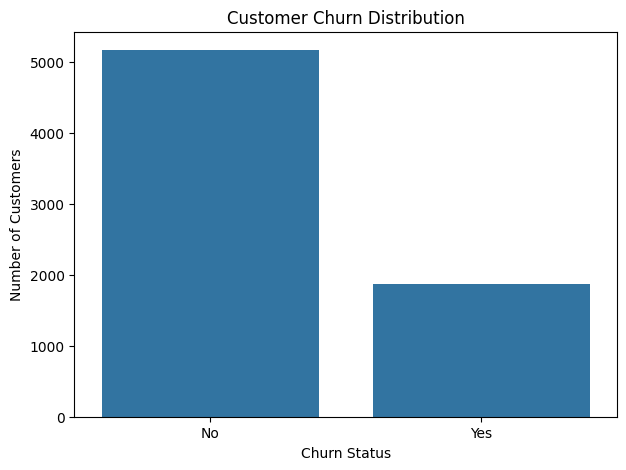

In [47]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=telco_clean,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.show()

In [48]:
total_customers = len(telco_clean)
churned_customers = (telco_clean["Churn"] == "Yes").sum()
retained_customers = (telco_clean["Churn"] == "No").sum()

churn_rate = churned_customers / total_customers * 100
retention_rate = retained_customers / total_customers * 100

print(f"Total Customers    : {total_customers}")
print(f"Churned Customers  : {churned_customers}")
print(f"Retained Customers : {retained_customers}")
print(f"Churn Rate         : {churn_rate:.2f}%")
print(f"Retention Rate     : {retention_rate:.2f}%")

Total Customers    : 7043
Churned Customers  : 1869
Retained Customers : 5174
Churn Rate         : 26.54%
Retention Rate     : 73.46%


#### Observation

Among the 7,043 customers represented in the dataset:

- 5,174 customers (73.46%) are classified as retained.
- 1,869 customers (26.54%) are classified as churned.

Therefore, approximately one-quarter of the customers in the dataset belong to the churn class.

#### Business Interpretation

The churn group represents a substantial portion of the observed customer base, making customer retention a meaningful business problem in this dataset.

Rather than treating churn prediction only as a classification task, the business objective should be to identify customers with elevated churn risk early enough to prioritize appropriate retention efforts.

The unequal class distribution also reinforces the need to evaluate future models using metrics beyond accuracy. In particular, the business consequences of failing to identify actual churners will need to be considered when evaluating recall, precision, F1-score, ROC-AUC, PR-AUC, and the final classification threshold.

## 4.2 - Does customer tenure influence churn? :

### Business Question

Does customer tenure influence the likelihood of churn?

### Hypothesis

Customers with shorter tenure may have a higher likelihood of churn because they have had less time to establish a relationship with the company and may have lower switching costs or weaker commitment.

This hypothesis will be tested using both numerical summaries and segment-level churn rates rather than relying only on average tenure.

#### 4.2.2 First comparison: average and median tenure :

In [49]:
telco_clean.groupby("Churn")["tenure"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

,count,mean,median,std,min,max
Churn,,,,,,
No,5174,37.569965,38.0,24.113777,0,72
Yes,1869,17.979133,10.0,19.531123,1,72


#### 4.2.3 Visualising the distributions :

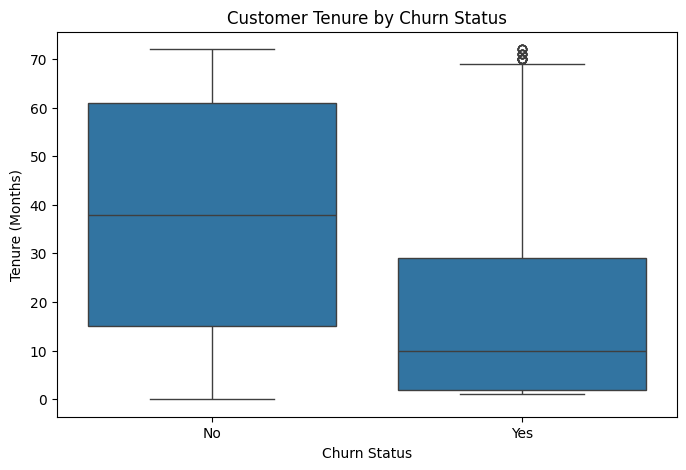

In [50]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=telco_clean,
    x="Churn",
    y="tenure"
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Tenure (Months)")

plt.show()

#### 4.2.4 Churn Rate by Customer Tenure :

In [51]:
tenure_bins = [0, 6, 12, 24, 48, 72]
tenure_labels = [
    "0–6 months",
    "7–12 months",
    "13–24 months",
    "25–48 months",
    "49–72 months"
]

telco_clean["TenureGroup"] = pd.cut(
    telco_clean["tenure"],
    bins=tenure_bins,
    labels=tenure_labels,
    include_lowest=True
)

tenure_churn = (
    telco_clean.groupby("TenureGroup", observed=True)["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

tenure_churn

TenureGroup
0–6 months      52.937205
7–12 months     35.886525
13–24 months    28.710938
25–48 months    20.388959
49–72 months     9.513176
Name: Churn, dtype: float64

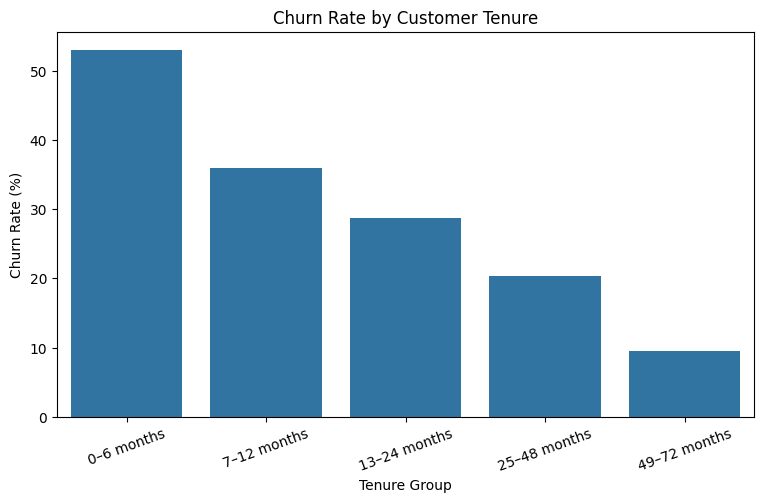

In [52]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=tenure_churn.index,
    y=tenure_churn.values
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)

plt.show()

### 4.3 Contract Type & Churn :

#### Business Question

Does the type of contract a customer has influence their likelihood of churning?

#### Hypothesis

Customers with month-to-month contracts may have a higher churn rate than customers with one-year or two-year contracts because longer contracts represent greater commitment and may reduce the likelihood of switching.

This hypothesis will first be evaluated using observed churn rates across contract groups.

However, contract type may also be associated with other customer characteristics, particularly tenure and pricing. Therefore, a difference in churn rates between contract types will not automatically be interpreted as a causal effect.

#### 4.3.1 How many customers are in each contract group? 

In [53]:
telco_clean["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

#### 4.3.2 Calculate churn rate by contract :

In [54]:
contract_churn = (
    telco_clean.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

contract_churn

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64

#### 4.3.3 Visualising it :

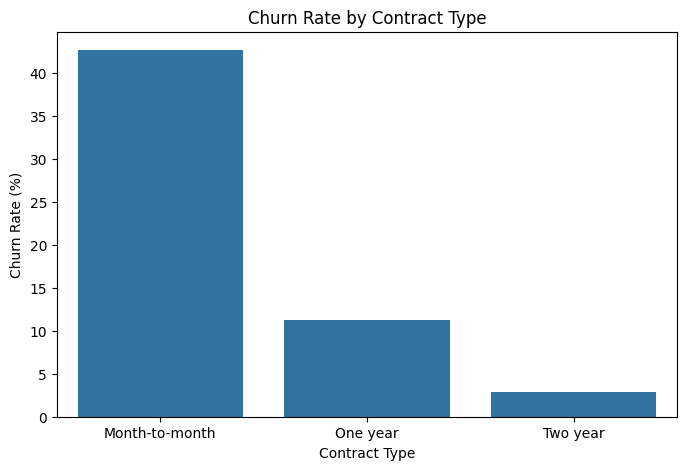

In [55]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=contract_churn.index,
    y=contract_churn.values
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.show()

#### 4.3.4 Creating a Contract × Tenure × Churn analysis :

In [56]:
telco_clean.groupby("Contract")["tenure"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Contract,,,,,
Month-to-month,3875,18.036645,12.0,1,72
One year,1473,42.044807,44.0,0,72
Two year,1695,56.735103,64.0,0,72


In [57]:
contract_tenure_churn = (
    telco_clean
    .groupby(["Contract", "TenureGroup"], observed=True)["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

contract_tenure_churn

,Contract,TenureGroup,ChurnRate
0,Month-to-month,0–6 months,55.201699
1,Month-to-month,7–12 months,41.996558
2,Month-to-month,13–24 months,37.720488
3,Month-to-month,25–48 months,32.917706
4,Month-to-month,49–72 months,26.023392
5,One year,0–6 months,10.256410
6,One year,7–12 months,10.588235
7,One year,13–24 months,8.121827
8,One year,25–48 months,10.617761
9,One year,49–72 months,12.933754


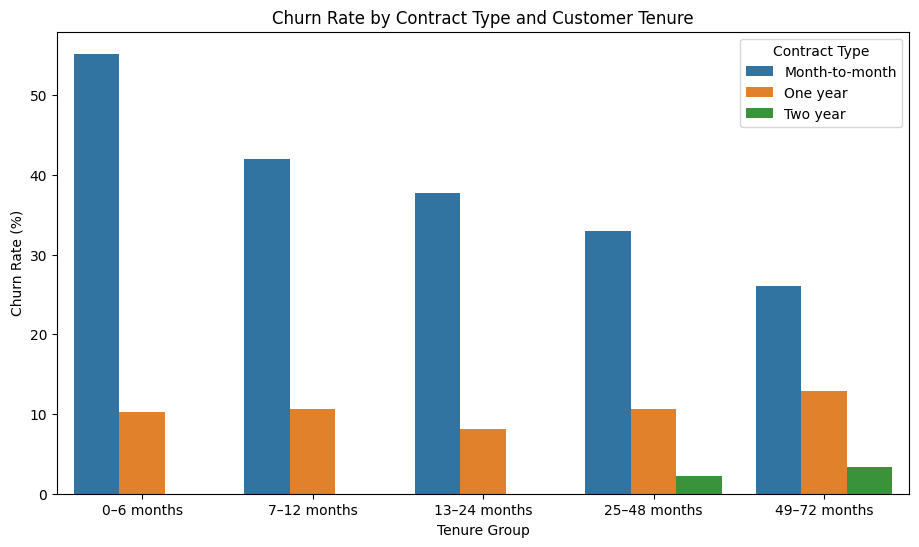

In [58]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=contract_tenure_churn,
    x="TenureGroup",
    y="ChurnRate",
    hue="Contract"
)

plt.title("Churn Rate by Contract Type and Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.legend(title="Contract Type")

plt.show()

##### Investigating the sample size :

In [59]:
contract_tenure_counts = (
    telco_clean
    .groupby(["Contract", "TenureGroup"], observed=True)
    .size()
    .reset_index(name="CustomerCount")
)

contract_tenure_counts

,Contract,TenureGroup,CustomerCount
0,Month-to-month,0–6 months,1413
1,Month-to-month,7–12 months,581
2,Month-to-month,13–24 months,737
3,Month-to-month,25–48 months,802
4,Month-to-month,49–72 months,342
5,One year,0–6 months,39
6,One year,7–12 months,85
7,One year,13–24 months,197
8,One year,25–48 months,518
9,One year,49–72 months,634


In [60]:
contract_tenure_analysis = contract_tenure_counts.merge(
    contract_tenure_churn,
    on=["Contract", "TenureGroup"]
)

contract_tenure_analysis

,Contract,TenureGroup,CustomerCount,ChurnRate
0,Month-to-month,0–6 months,1413,55.201699
1,Month-to-month,7–12 months,581,41.996558
2,Month-to-month,13–24 months,737,37.720488
3,Month-to-month,25–48 months,802,32.917706
4,Month-to-month,49–72 months,342,26.023392
5,One year,0–6 months,39,10.256410
6,One year,7–12 months,85,10.588235
7,One year,13–24 months,197,8.121827
8,One year,25–48 months,518,10.617761
9,One year,49–72 months,634,12.933754


#### Subgroup Sample Sizes - Observation :

The contract-by-tenure analysis was supplemented with customer counts to assess the reliability of subgroup churn rates.

The zero churn rates observed for some two-year contract groups are based on relatively small groups of 29, 39, and 90 customers. These estimates should therefore be interpreted cautiously rather than as evidence of zero underlying churn risk.

However, the two-year contract group with 49–72 months of tenure contains 1,263 customers and still shows a very low observed churn rate of approximately 3.3%. In contrast, month-to-month customers have substantially higher churn rates across all observed tenure groups, with considerably larger subgroup sizes.

#### Refined Business Interpretation

The evidence supports a strong association between contract type and observed churn, particularly for month-to-month customers. The relationship also persists across tenure groups, although its magnitude varies.

The analysis provides evidence for prioritizing month-to-month customers in retention analysis, especially during the early stages of the customer relationship.

However, contract type should not yet be interpreted as a causal driver of churn. Other customer characteristics, including pricing, services, payment method, and tenure, may jointly contribute to the observed relationship. These factors will be examined in subsequent multivariate analysis and ultimately evaluated together within the machine learning models.

### 4.4 Pricing and Customer Churn :

#### 4.4.1 Monthly Charges and Churn :

#### Business Question

Is the customer's current monthly charge associated with their likelihood of churning?

#### Hypothesis

Customers with higher monthly charges may exhibit higher churn rates if higher recurring costs increase price sensitivity or dissatisfaction.

However, monthly charges may also reflect the number or type of services a customer uses. Therefore, any observed relationship between monthly charges and churn will be treated as an association rather than a causal effect.

#### 4.4.2 Comparing the distributions :

In [61]:
telco_clean.groupby("Churn")["MonthlyCharges"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

,count,mean,median,std,min,max
Churn,,,,,,
No,5174,61.265124,64.425,31.092648,18.25,118.75
Yes,1869,74.441332,79.650,24.666053,18.85,118.35


#### 4.4.3 Visualising MonthlyCharges by churn :

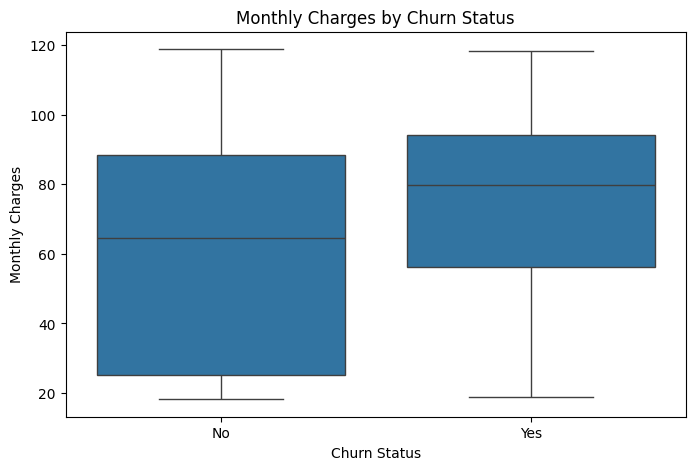

In [62]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=telco_clean,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")

plt.show()

In [63]:
telco_clean["MonthlyCharges"].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

#### 4.4.4 Total Charges and Churn :

#### Business Question

Do customers with different levels of accumulated charges exhibit different churn behaviour?

#### Hypothesis

Customers with higher accumulated charges may have lower churn because accumulated spending is partly related to longer customer tenure and an established relationship.

However, `TotalCharges` is strongly related to both tenure and monthly charges. Therefore, differences in TotalCharges between churn groups should not be interpreted independently of these variables.

In [64]:
telco_clean.groupby("Churn")["TotalCharges"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

,count,mean,median,std,min,max
Churn,,,,,,
No,5174,2549.911442,1679.525,2329.954215,0.00,8672.45
Yes,1869,1531.796094,703.550,1890.822994,18.85,8684.80


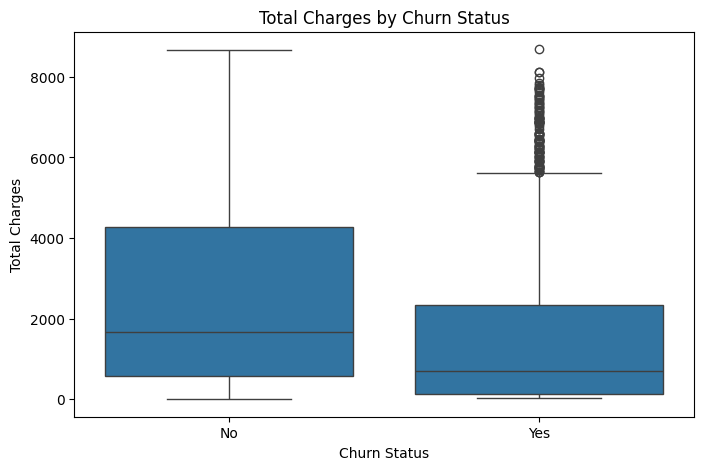

In [65]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=telco_clean,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Total Charges")

plt.show()

##### Observation :

Monthly charges show a noticeable difference between churned and retained customers. Churned customers have a higher median monthly charge (79.65) than retained customers (64.43), suggesting an association between higher recurring charges and churn.

Total charges show an even larger difference. The median accumulated charge is approximately 703.55 for churned customers compared with 1,679.53 for retained customers.

However, TotalCharges is strongly related to customer tenure because longer-tenured customers have had more time to accumulate charges. Therefore, the lower TotalCharges observed among churned customers should not be interpreted as evidence that lower cumulative spending directly causes churn.

The TotalCharges distribution also shows substantial right-skewness and several high-value observations, particularly among churned customers. These observations are not automatically considered errors and will be retained unless further analysis provides evidence that they are invalid.

Overall, the analysis suggests that pricing and accumulated customer value are associated with churn, but the relationships may be influenced by other variables such as tenure, contract type, and subscribed services.

#### 4.4.5 Monthly Charge Segmentation :

#### Business Question

Does the observed churn rate differ across customer groups based on their monthly charges?

#### Approach

Rather than selecting arbitrary charge thresholds, customers will be divided into quantile-based groups using `qcut()`.

This allows us to compare churn across approximately equal-sized customer segments and identify whether higher monthly charges are associated with systematically different churn rates.

The resulting segments are used for exploratory analysis only and will not automatically become model features.

In [66]:
telco_clean["MonthlyChargeGroup"] = pd.qcut(
    telco_clean["MonthlyCharges"],
    q=4,
    labels=["Q1 - Lowest", "Q2", "Q3", "Q4 - Highest"]
)

In [67]:
telco_clean.groupby(
    "MonthlyChargeGroup",
    observed=True
)["MonthlyCharges"].agg(
    ["count", "min", "max", "mean", "median"]
)

,count,min,max,mean,median
MonthlyChargeGroup,,,,,
Q1 - Lowest,1762,18.25,35.50,22.230306,20.30
Q2,1766,35.55,70.35,55.729360,55.15
Q3,1757,70.40,89.85,80.334861,80.20
Q4 - Highest,1758,89.90,118.75,100.898976,100.20


In [68]:
monthly_charge_churn = (
    telco_clean
    .groupby("MonthlyChargeGroup", observed=True)["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

monthly_charge_churn

MonthlyChargeGroup
Q1 - Lowest     11.237230
Q2              24.575311
Q3              37.507114
Q4 - Highest    32.878271
Name: Churn, dtype: float64

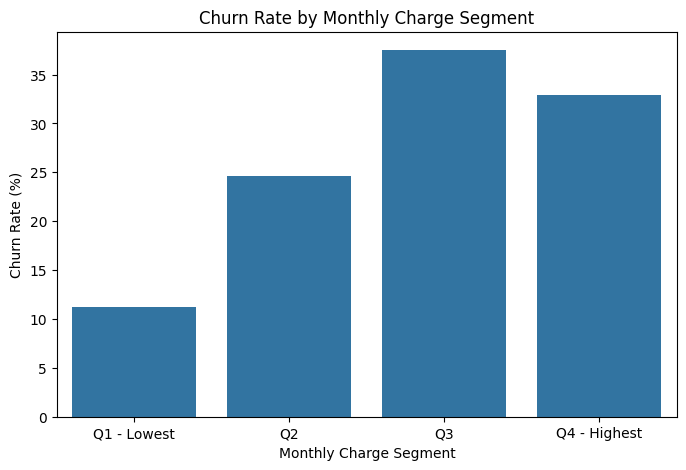

In [69]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=monthly_charge_churn.index,
    y=monthly_charge_churn.values
)

plt.title("Churn Rate by Monthly Charge Segment")
plt.xlabel("Monthly Charge Segment")
plt.ylabel("Churn Rate (%)")

plt.show()

#### Observation :

Customers were divided into four approximately equal-sized groups based on their monthly charges using quantile-based segmentation.

The observed churn rate increased substantially from the lowest-charge segment (11.24%) to the middle-upper charge segments, reaching a maximum of 37.51% in Q3. However, churn decreased slightly to 32.88% in the highest-charge segment.

Therefore, the relationship between monthly charges and churn is not strictly monotonic. Higher monthly charges are associated with substantially higher observed churn compared with the lowest-charge group, but the highest-charge group does not have the highest churn rate.

#### Business Interpretation :

The results suggest that pricing is potentially an important dimension of churn risk, particularly for customers in the upper monthly-charge range. However, the non-monotonic pattern indicates that monthly charges alone are unlikely to explain churn.

Monthly charges may reflect differences in contract type, tenure, subscribed services, or customer segments. Therefore, the observed relationship should be treated as an association rather than evidence that higher prices directly cause churn.

This finding supports the need for multivariate analysis, where pricing can be evaluated together with contract, tenure, services, and other customer characteristics. 

### 4.5 Demographics and Customer Churn :

#### 4.5.1 Senior Citizen Status and Churn :

#### Business Question

Does churn behaviour differ between senior and non-senior customers?

#### Hypothesis

Senior and non-senior customers may exhibit different churn patterns due to differences in customer needs, service preferences, or usage behaviour.

The analysis will determine whether a meaningful difference exists in the observed churn rates.

Demographic differences will be interpreted cautiously and will not automatically be treated as actionable business drivers.

In [70]:
senior_churn = (
    telco_clean.groupby("SeniorCitizen")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)
senior_churn

SeniorCitizen
0    23.606168
1    41.681261
Name: Churn, dtype: float64

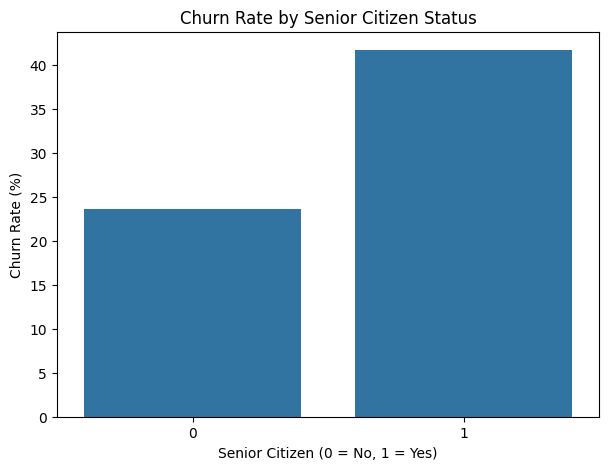

In [71]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=senior_churn.index,
    y=senior_churn.values
)

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Churn Rate (%)")

plt.show()

In [72]:
telco_clean["SeniorCitizen"].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

#### Observation :

Senior customers represent 1,142 of the 7,043 customers in the dataset, while non-senior customers represent 5,901 customers.

The observed churn rate among senior customers is approximately 41.7%, compared with approximately 23.6% among non-senior customers. This represents a substantial difference in observed churn behaviour.

#### Business Interpretation :

Senior-citizen status appears to be associated with higher churn in the observed dataset and may provide useful predictive information for the machine learning models.

However, this relationship should not be interpreted as causal. Senior status may be associated with other customer characteristics such as contract type, tenure, pricing, and service usage.

Furthermore, predictive usefulness does not automatically imply that a demographic variable should be used directly for customer targeting or retention decisions. Its eventual role should be considered alongside model performance, business appropriateness, and fairness considerations.

#### 4.5.2 Household Characteristics and Churn :

#### Business Question :

Do customers with partners or dependents exhibit different churn behaviour?

#### Hypothesis :

Customers with partners or dependents may have different retention patterns because household circumstances can influence service needs, customer commitment, and switching decisions.

These relationships will be treated as associations rather than causal effects.

In [73]:
household_cols = ["Partner", "Dependents"]

for col in household_cols:
    churn_rate = (
        telco_clean.groupby(col)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
    )
    
    counts = telco_clean[col].value_counts()
    
    print(f"\n--- {col} ---")
    print("Customer Count:")
    print(counts)
    print("\nChurn Rate (%):")
    print(churn_rate.round(2))


--- Partner ---
Customer Count:
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Churn Rate (%):
Partner
No     32.96
Yes    19.66
Name: Churn, dtype: float64

--- Dependents ---
Customer Count:
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

Churn Rate (%):
Dependents
No     31.28
Yes    15.45
Name: Churn, dtype: float64


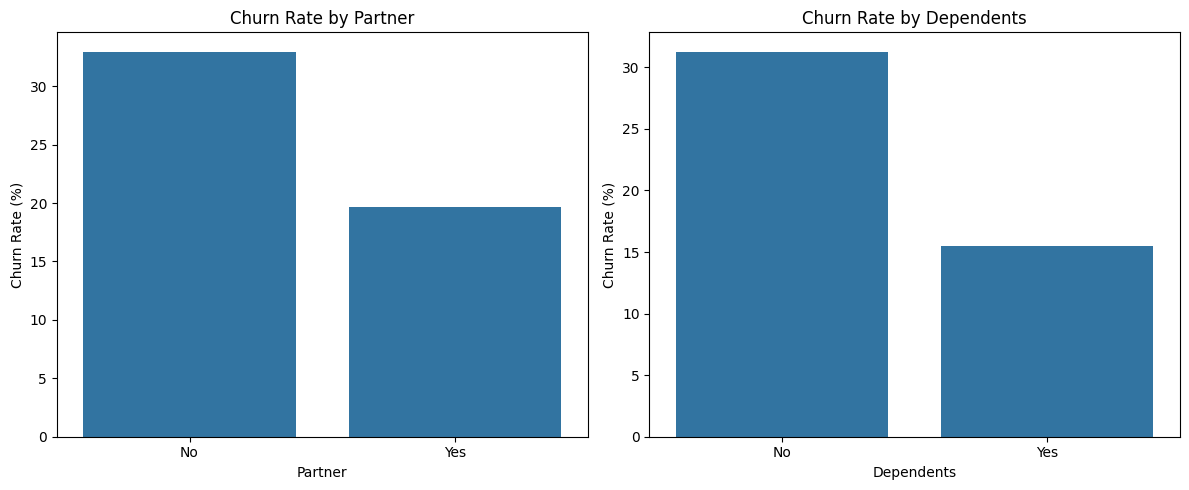

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col in zip(axes, household_cols):
    churn_rate = (
        telco_clean.groupby(col)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
    )
    
    sns.barplot(
        x=churn_rate.index,
        y=churn_rate.values,
        ax=ax
    )
    
    ax.set_title(f"Churn Rate by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

#### Observation :

Customers with partners show a substantially lower observed churn rate than customers without partners (19.66% vs 32.96%).

A similar pattern is observed for dependents. Customers with dependents have an observed churn rate of 15.45%, compared with 31.28% for customers without dependents.

Both household-related variables therefore show notable associations with churn.

#### Business Interpretation :

Customers with partners or dependents appear to have lower observed churn rates in this dataset. One possible interpretation is that household circumstances may be associated with greater service stability or different customer behaviour.

However, these relationships should not be interpreted as causal. Partner and dependent status may be related to other characteristics such as tenure, contract type, services, and pricing. Therefore, these variables will be evaluated together with other predictors during multivariate analysis and machine learning.

The findings suggest that household characteristics may provide useful segmentation information, but they should not be treated as direct explanations for customer churn without further analysis. 

#### 4.5.3 What about Gender? 

In [75]:
gender_churn = (
    telco_clean.groupby("gender")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print("Customer Count:")
print(telco_clean["gender"].value_counts())

print("\nChurn Rate (%):")
print(gender_churn.round(2))

Customer Count:
gender
Male      3555
Female    3488
Name: count, dtype: int64

Churn Rate (%):
gender
Female    26.92
Male      26.16
Name: Churn, dtype: float64


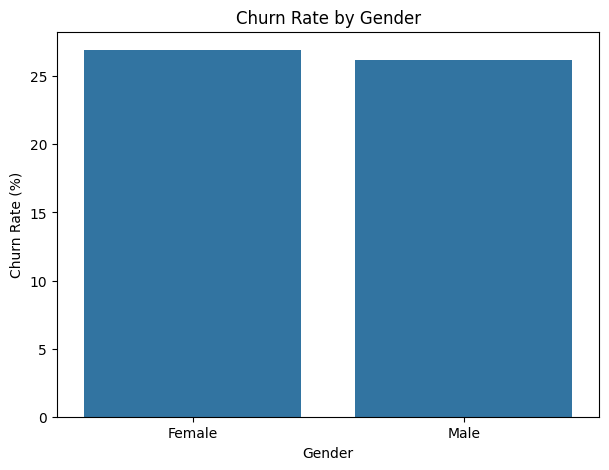

In [76]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=gender_churn.index,
    y=gender_churn.values
)

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")

plt.show()

### 4.6 Services & Churn :

#### First - Understanding the service structure :

In [77]:
service_cols = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

#### 4.6.1 Internet Service and Churn

#### Business Question

Does the type of internet service a customer uses relate to their likelihood of churning?

#### Hypothesis

Customers using different internet service types may exhibit different churn behaviour because service technology, pricing, customer experience, and subscribed features may differ across groups.

The analysis will compare observed churn rates across internet service types. Any relationship will be interpreted as an association rather than evidence that a particular internet technology directly causes churn.

In [78]:
telco_clean["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [79]:
internet_churn = (
    telco_clean
    .groupby("InternetService")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)
internet_churn

InternetService
DSL            18.959108
Fiber optic    41.892765
No              7.404980
Name: Churn, dtype: float64

In [80]:
internet_analysis = pd.DataFrame({
    "CustomerCount": telco_clean["InternetService"].value_counts(),
    "ChurnRate": internet_churn
})
internet_analysis

,CustomerCount,ChurnRate
InternetService,,
DSL,2421,18.959108
Fiber optic,3096,41.892765
No,1526,7.404980


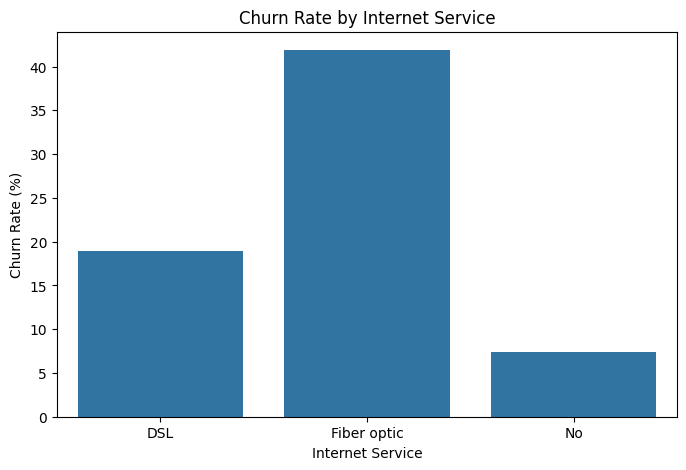

In [81]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=internet_churn.index,
    y=internet_churn.values
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

plt.show()

#### Observation :

Internet service type shows a substantial association with customer churn.

Fiber-optic customers have the highest observed churn rate at approximately 41.89%, compared with 18.96% for DSL customers and 7.40% for customers without internet service.

The difference is substantial and suggests that internet service type may contain useful predictive information.

#### Business Interpretation :

Fiber-optic customers represent a potentially important high-risk segment for further investigation. However, the observed relationship should not be interpreted as evidence that fiber-optic service itself causes churn.

Fiber customers may differ from other groups in terms of monthly charges, contract type, tenure, payment method, and additional services. These characteristics may partially explain the observed churn difference.

Customers without internet service show a substantially lower observed churn rate. However, this group also has structurally different service attributes because several internet-dependent service variables automatically take the value "No internet service."

Therefore, subsequent service analysis will account for the hierarchical relationship between InternetService and dependent service features rather than treating every service variable as independent. 

#### 4.6.2 Now let's analyze the individual services :

In [82]:
def churn_analysis(data, column):
    analysis = (
        data.groupby(column)["Churn"]
        .agg(
            CustomerCount="size",
            ChurnRate=lambda x: (x == "Yes").mean() * 100
        )
        .sort_values("ChurnRate", ascending=False)
    )
    
    return analysis

In [83]:
churn_analysis(telco_clean, "OnlineSecurity")

,CustomerCount,ChurnRate
OnlineSecurity,,
No,3498,41.766724
Yes,2019,14.611194
No internet service,1526,7.404980


In [84]:
churn_analysis(telco_clean, "TechSupport")

,CustomerCount,ChurnRate
TechSupport,,
No,3473,41.635474
Yes,2044,15.166341
No internet service,1526,7.404980


In [85]:
churn_analysis(telco_clean, "DeviceProtection")

,CustomerCount,ChurnRate
DeviceProtection,,
No,3095,39.127625
Yes,2422,22.502064
No internet service,1526,7.404980


#### 4.6.3 Analysing the six conditional services :

In [86]:
conditional_services = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

for service in conditional_services:
    print(f"\n{'=' * 50}")
    print(service,":")
    print('=' * 50)
    print(churn_analysis(telco_clean, service).round(2))


OnlineSecurity :
                     CustomerCount  ChurnRate
OnlineSecurity                               
No                            3498      41.77
Yes                           2019      14.61
No internet service           1526       7.40

OnlineBackup :
                     CustomerCount  ChurnRate
OnlineBackup                                 
No                            3088      39.93
Yes                           2429      21.53
No internet service           1526       7.40

DeviceProtection :
                     CustomerCount  ChurnRate
DeviceProtection                             
No                            3095      39.13
Yes                           2422      22.50
No internet service           1526       7.40

TechSupport :
                     CustomerCount  ChurnRate
TechSupport                                  
No                            3473      41.64
Yes                           2044      15.17
No internet service           1526       7.40

StreamingT

#### 4.6.4 InternetService × OnlineSecurity :

In [87]:
pd.crosstab(
    telco_clean["InternetService"],
    telco_clean["OnlineSecurity"]
)

OnlineSecurity,No,No internet service,Yes
InternetService,,,
DSL,1241,0,1180
Fiber optic,2257,0,839
No,0,1526,0


In [88]:
pd.crosstab(
    telco_clean["InternetService"],
    telco_clean["TechSupport"]
)

TechSupport,No,No internet service,Yes
InternetService,,,
DSL,1243,0,1178
Fiber optic,2230,0,866
No,0,1526,0


In [89]:
pd.crosstab(
    telco_clean["InternetService"],
    telco_clean["OnlineSecurity"],
    normalize="index"
).round(3)

OnlineSecurity,No,No internet service,Yes
InternetService,,,
DSL,0.513,0.0,0.487
Fiber optic,0.729,0.0,0.271
No,0.000,1.0,0.000


In [90]:
pd.crosstab(
    telco_clean["InternetService"],
    telco_clean["TechSupport"],
    normalize="index"
).round(3)

TechSupport,No,No internet service,Yes
InternetService,,,
DSL,0.513,0.0,0.487
Fiber optic,0.720,0.0,0.280
No,0.000,1.0,0.000


#### Observation :

The six conditional service features show different levels of association with customer churn.

OnlineSecurity and TechSupport show the strongest differences. Customers without OnlineSecurity have an observed churn rate of 41.77%, compared with 14.61% among customers who subscribe to the service. Similarly, customers without TechSupport have a churn rate of 41.64%, compared with 15.17% among customers with TechSupport.

OnlineBackup and DeviceProtection also show notable differences. Customers without these services have churn rates of 39.93% and 39.13%, respectively, while customers with these services have lower churn rates of 21.53% and 22.50%.

In contrast, StreamingTV and StreamingMovies show much smaller differences. Churn rates differ by only a few percentage points between customers who subscribe and those who do not.

The "No internet service" category has the same 7.40% churn rate across all six variables because it represents the same underlying group of customers who do not have an internet service. Therefore, these repeated values should not be interpreted as six independent findings.

Overall, security, support, backup, and device-protection services show stronger associations with churn than entertainment-oriented streaming services. However, these associations do not establish that subscribing to these services directly reduces churn.

The service variables may be related to other characteristics such as InternetService, contract type, tenure, and monthly charges. Further multivariate analysis is therefore required to determine whether these services provide independent predictive information. 

#### 4.6.5 InternetService × OnlineSecurity × Churn :

In [91]:
security_segment = (
    telco_clean[
        telco_clean["InternetService"] != "No"
    ]
    .groupby(["InternetService", "OnlineSecurity"])["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

security_segment

,InternetService,OnlineSecurity,ChurnRate
0,DSL,No,27.961322
1,DSL,Yes,9.491525
2,Fiber optic,No,49.357554
3,Fiber optic,Yes,21.811681


In [92]:
support_segment = (
    telco_clean[
        telco_clean["InternetService"] != "No"
    ]
    .groupby(["InternetService", "TechSupport"])["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

support_segment

,InternetService,TechSupport,ChurnRate
0,DSL,No,27.755430
1,DSL,Yes,9.677419
2,Fiber optic,No,49.372197
3,Fiber optic,Yes,22.632794


#### Observation - Stratified Service Analysis :

The relationship between OnlineSecurity, TechSupport, and churn remains strong after stratifying customers by InternetService.

Among DSL customers, churn is 27.96% for customers without OnlineSecurity compared with 9.49% for customers with OnlineSecurity. Among fiber-optic customers, the corresponding churn rates are 49.36% and 21.81%.

A similar pattern is observed for TechSupport. Among DSL customers, churn is 27.76% without TechSupport compared with 9.68% with TechSupport. Among fiber-optic customers, churn is 49.37% without TechSupport compared with 22.63% with TechSupport.

Therefore, the observed association between security/support services and lower churn is not entirely explained by InternetService alone.

Fiber-optic customers continue to exhibit higher churn within both service-subscription groups, indicating that InternetService and security/support subscriptions may each contain useful information about churn risk.

#### Business Insight :

The combination of fiber-optic service and absence of OnlineSecurity or TechSupport represents a particularly high-churn customer segment in this dataset. This segment may warrant further investigation as a potential retention priority.

However, these findings represent observational associations and do not establish that subscribing to OnlineSecurity or TechSupport directly causes customers to remain. 

#### 4.6.6 Phone Service and Multiple Lines :

#### Business Question :

Does having phone service, and subsequently having multiple phone lines, relate to customer churn?

#### Analytical Consideration :

MultipleLines is structurally related to PhoneService. Customers without phone service cannot have multiple lines, so the "No phone service" category in MultipleLines should not be interpreted as an independent customer choice. 

In [93]:
churn_analysis(telco_clean, "PhoneService")

,CustomerCount,ChurnRate
PhoneService,,
Yes,6361,26.709637
No,682,24.926686


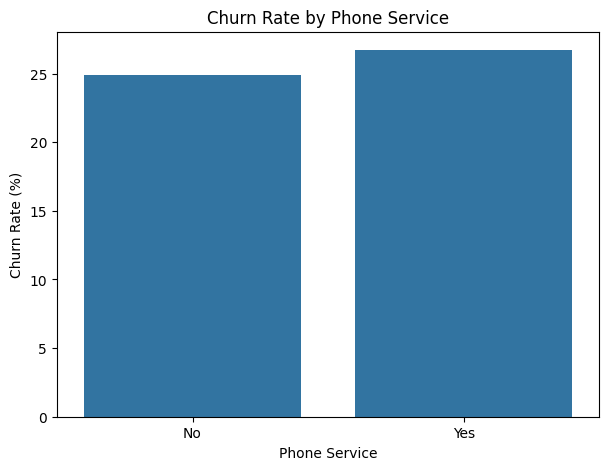

In [94]:
phone_churn = (
    telco_clean.groupby("PhoneService")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=phone_churn.index,
    y=phone_churn.values
)

plt.title("Churn Rate by Phone Service")
plt.xlabel("Phone Service")
plt.ylabel("Churn Rate (%)")

plt.show()

In [95]:
churn_analysis(telco_clean, "MultipleLines")

,CustomerCount,ChurnRate
MultipleLines,,
Yes,2971,28.609896
No,3390,25.044248
No phone service,682,24.926686


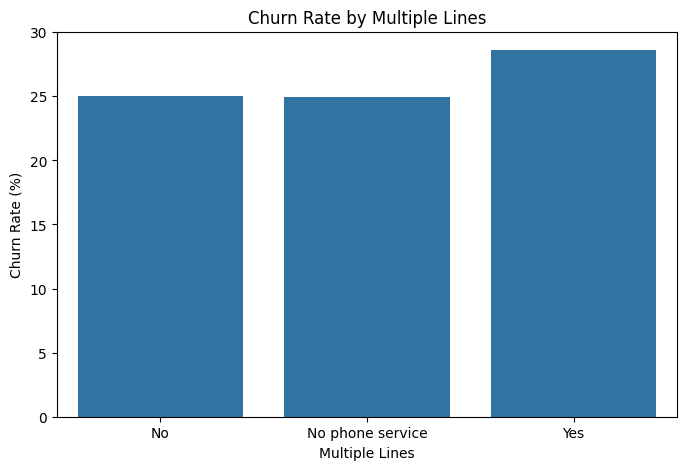

In [96]:
multiple_lines_churn = (
    telco_clean.groupby("MultipleLines")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=multiple_lines_churn.index,
    y=multiple_lines_churn.values
)

plt.title("Churn Rate by Multiple Lines")
plt.xlabel("Multiple Lines")
plt.ylabel("Churn Rate (%)")

plt.show()

In [97]:
pd.crosstab(
    telco_clean["PhoneService"],
    telco_clean["MultipleLines"]
)

MultipleLines,No,No phone service,Yes
PhoneService,,,
No,0,682,0
Yes,3390,0,2971


In [98]:
phone_customers = telco_clean[
    telco_clean["PhoneService"] == "Yes"
]

In [99]:
multiple_lines_phone = (
    phone_customers
    .groupby("MultipleLines")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

multiple_lines_phone.round(2)

MultipleLines
No     25.04
Yes    28.61
Name: Churn, dtype: float64

#### Observation :

PhoneService shows only a small difference in observed churn rates. Customers with phone service have a churn rate of 26.71%, compared with 24.93% among customers without phone service.

MultipleLines shows a somewhat larger but still relatively modest difference. Among customers with phone service, customers with multiple lines have a churn rate of approximately 28.61%, compared with approximately 25.04% for customers without multiple lines.

The "No phone service" category in MultipleLines is structurally determined by the absence of PhoneService and therefore should not be interpreted as an independent customer choice.

Overall, PhoneService and MultipleLines appear to have weaker associations with churn than features such as Contract, InternetService, OnlineSecurity, and TechSupport. Their predictive contribution will ultimately be determined during multivariate modelling rather than based solely on these univariate differences. 

### 4.7 Contract, Payment & Billing :


#### 4.7.1 Contract Type and Churn :

#### Business Question :

Does the level of contractual commitment relate to customer churn?

#### Hypothesis :

Customers on month-to-month contracts may have higher churn because they have greater flexibility to leave, while customers on longer-term contracts may show greater retention due to stronger contractual commitment.

This analysis will examine the observed relationship between contract type and churn. It will not be interpreted as proof that contract duration itself causes retention.

In [100]:
telco_clean["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [101]:
contract_analysis = churn_analysis(
    telco_clean,
    "Contract"
)

contract_analysis.round(2)

,CustomerCount,ChurnRate
Contract,,
Month-to-month,3875,42.71
One year,1473,11.27
Two year,1695,2.83


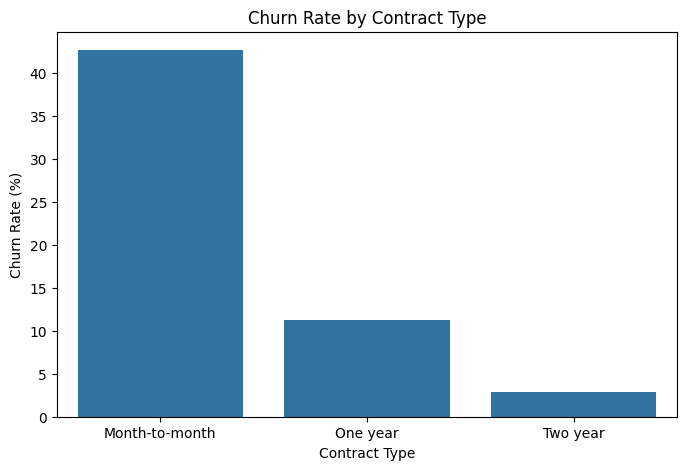

In [102]:
contract_churn = (
    telco_clean
    .groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=contract_churn.index,
    y=contract_churn.values
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.show()

#### 4.7.2 Contract × Tenure :

In [103]:
contract_tenure = (
    telco_clean
    .groupby(["Contract", "TenureGroup"], observed=True)["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

contract_tenure

,Contract,TenureGroup,ChurnRate
0,Month-to-month,0–6 months,55.201699
1,Month-to-month,7–12 months,41.996558
2,Month-to-month,13–24 months,37.720488
3,Month-to-month,25–48 months,32.917706
4,Month-to-month,49–72 months,26.023392
5,One year,0–6 months,10.256410
6,One year,7–12 months,10.588235
7,One year,13–24 months,8.121827
8,One year,25–48 months,10.617761
9,One year,49–72 months,12.933754


#### Contract Type — Previously Analyzed:

Contract type and its relationship with customer churn were analyzed earlier in the EDA, including the interaction between contract type and customer tenure.

The analysis showed substantially higher observed churn among month-to-month customers, with the difference remaining evident across tenure groups.

Therefore, the analysis is not repeated here. The findings will be carried forward into the commercial-risk and multivariate analysis stages. 

#### 4.7.2 Payment Method and Churn :

#### Business Question :

Does the customer's payment method relate to their likelihood of churning?

#### Why This Matters :

Payment behaviour may reflect differences in customer preferences, billing experience, payment friction, or customer engagement.

If certain payment methods are associated with substantially higher churn, they may identify customer segments that deserve further investigation.

However, the payment method itself should not automatically be interpreted as the cause of churn. 

In [104]:
telco_clean["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [105]:
telco_clean["PaymentMethod"].value_counts(normalize=True).mul(100).round(2)

PaymentMethod
Electronic check             33.58
Mailed check                 22.89
Bank transfer (automatic)    21.92
Credit card (automatic)      21.61
Name: proportion, dtype: float64

In [106]:
payment_analysis = churn_analysis(
    telco_clean,
    "PaymentMethod"
)

payment_analysis.round(2)

,CustomerCount,ChurnRate
PaymentMethod,,
Electronic check,2365,45.29
Mailed check,1612,19.11
Bank transfer (automatic),1544,16.71
Credit card (automatic),1522,15.24


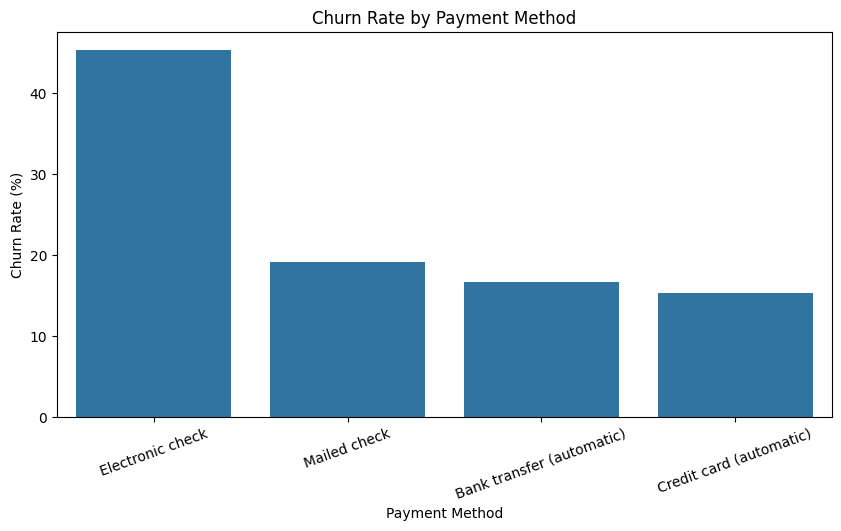

In [107]:
payment_churn = (
    telco_clean
    .groupby("PaymentMethod")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=payment_churn.index,
    y=payment_churn.values
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)

plt.show()

#### 4.7.3 Payment Method × Contract :

In [108]:
pd.crosstab(
    telco_clean["PaymentMethod"],
    telco_clean["Contract"],
    normalize="index"
).round(3)

Contract,Month-to-month,One year,Two year
PaymentMethod,,,
Bank transfer (automatic),0.381,0.253,0.365
Credit card (automatic),0.357,0.261,0.382
Electronic check,0.782,0.147,0.071
Mailed check,0.554,0.209,0.237


In [109]:
payment_contract_churn = (
    telco_clean
    .groupby(["Contract", "PaymentMethod"])["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

payment_contract_churn.round(2)

,Contract,PaymentMethod,ChurnRate
0,Month-to-month,Bank transfer (automatic),34.13
1,Month-to-month,Credit card (automatic),32.78
2,Month-to-month,Electronic check,53.73
3,Month-to-month,Mailed check,31.58
4,One year,Bank transfer (automatic),9.72
5,One year,Credit card (automatic),10.30
6,One year,Electronic check,18.44
7,One year,Mailed check,6.82
8,Two year,Bank transfer (automatic),3.37
9,Two year,Credit card (automatic),2.24


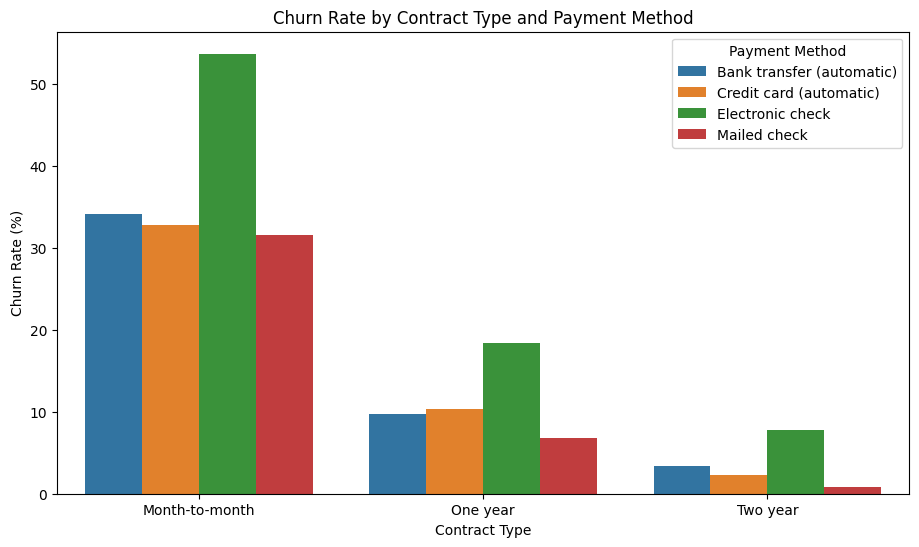

In [110]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=payment_contract_churn,
    x="Contract",
    y="ChurnRate",
    hue="PaymentMethod"
)

plt.title("Churn Rate by Contract Type and Payment Method")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.legend(title="Payment Method")

plt.show()

#### Observation :

Electronic check shows the highest overall churn rate among the four payment methods. Importantly, the association remains visible after stratifying customers by contract type.

Among month-to-month customers, electronic-check users have a churn rate of 53.73%, compared with approximately 31.58%–34.13% for the other payment methods. A similar pattern is observed for one-year and two-year contracts, where electronic-check customers also exhibit higher observed churn.

This indicates that the high churn associated with electronic check is not fully explained by the strong relationship between electronic check and month-to-month contracts.

However, the analysis remains observational and does not establish that payment method causes churn. Additional factors such as tenure, monthly charges, internet service, and customer service subscriptions may contribute to the observed relationship.

Customer segment sizes will also be considered before drawing business conclusions, since churn percentages from very small groups may be unstable. 

In [111]:
payment_contract_counts = (
    telco_clean
    .groupby(["Contract", "PaymentMethod"])
    .size()
    .reset_index(name="CustomerCount")
)

payment_contract_counts

,Contract,PaymentMethod,CustomerCount
0,Month-to-month,Bank transfer (automatic),589
1,Month-to-month,Credit card (automatic),543
2,Month-to-month,Electronic check,1850
3,Month-to-month,Mailed check,893
4,One year,Bank transfer (automatic),391
5,One year,Credit card (automatic),398
6,One year,Electronic check,347
7,One year,Mailed check,337
8,Two year,Bank transfer (automatic),564
9,Two year,Credit card (automatic),581


#### Observation :

Electronic check shows the highest observed churn rate within every contract category.

Among month-to-month customers, electronic-check users have a churn rate of 53.73%, compared with 31.58%–34.13% for the other payment methods. The same pattern is observed among one-year and two-year customers, where electronic-check users also exhibit the highest churn.

Therefore, the strong relationship between electronic check and churn is not fully explained by contract type alone.

However, this analysis is observational and should not be interpreted as evidence that payment method causes churn. Other customer characteristics may contribute to the relationship. Segment sizes will also be considered before assessing the practical business significance of these differences. 

#### 4.7.4 Paperless Billing and Churn :
 
#### Business Question :

Does the customer's paperless billing preference relate to their likelihood of churning?

#### Why This Matters :

Billing preferences may reflect differences in customer behaviour, engagement, convenience, or customer segment characteristics.

Understanding this relationship can help identify customer groups that may require further investigation during retention analysis.

The observed relationship will be treated as an association rather than evidence that paperless billing directly causes churn.

In [112]:
telco_clean["PaperlessBilling"].value_counts()

PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64

In [113]:
telco_clean["PaperlessBilling"].value_counts(
    normalize=True
).mul(100).round(2)

PaperlessBilling
Yes    59.22
No     40.78
Name: proportion, dtype: float64

In [114]:
paperless_analysis = churn_analysis(
    telco_clean,
    "PaperlessBilling"
)

paperless_analysis.round(2)

,CustomerCount,ChurnRate
PaperlessBilling,,
Yes,4171,33.57
No,2872,16.33


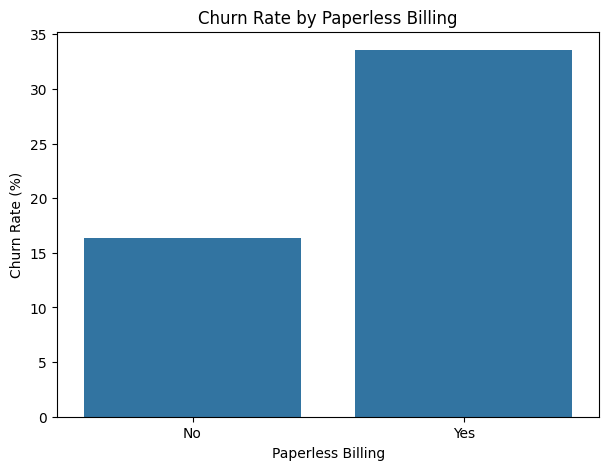

In [115]:
paperless_churn = (
    telco_clean
    .groupby("PaperlessBilling")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=paperless_churn.index,
    y=paperless_churn.values
)

plt.title("Churn Rate by Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Churn Rate (%)")

plt.show()

#### Checking Paperless Billing × Contract × Churn :

In [116]:
pd.crosstab(
    telco_clean["PaperlessBilling"],
    telco_clean["Contract"],
    normalize="index"
).round(3)

Contract,Month-to-month,One year,Two year
PaperlessBilling,,,
No,0.449,0.234,0.317
Yes,0.620,0.192,0.188


In [117]:
paperless_contract_churn = (
    telco_clean
    .groupby(
        ["Contract", "PaperlessBilling"]
    )["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

paperless_contract_churn.round(2)

,Contract,PaperlessBilling,ChurnRate
0,Month-to-month,No,31.50
1,Month-to-month,Yes,48.30
2,One year,No,7.13
3,One year,Yes,14.75
4,Two year,No,1.65
5,Two year,Yes,4.20


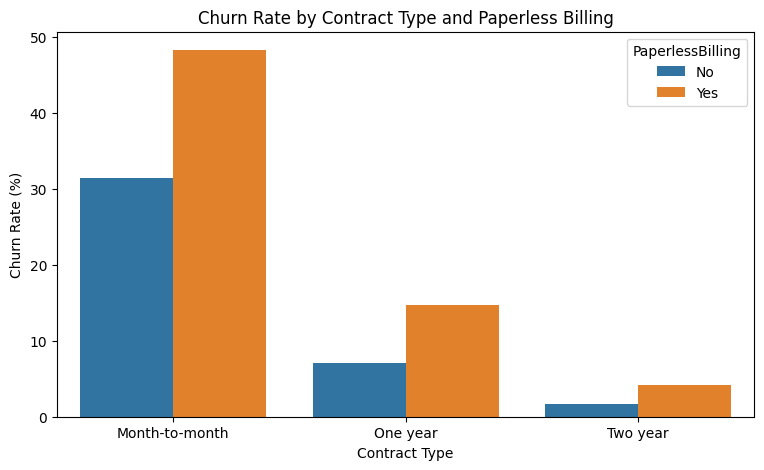

In [118]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=paperless_contract_churn,
    x="Contract",
    y="ChurnRate",
    hue="PaperlessBilling"
)

plt.title("Churn Rate by Contract Type and Paperless Billing")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.show()

#### Observation :

Customers using paperless billing show a substantially higher observed churn rate than customers not using paperless billing.

The relationship persists after stratifying customers by contract type. Paperless-billing customers have higher churn rates within month-to-month, one-year, and two-year contracts.

This suggests that the association between paperless billing and churn is not fully explained by contract type alone. However, the analysis is observational and does not establish that paperless billing causes churn. Other customer characteristics may contribute to the observed relationship.

### 4.8 Monthly Charges and Churn :

#### Business Question :

Is customer monthly spending associated with churn?

#### Why This Matters :

Monthly charges represent an ongoing revenue relationship between the customer and the company.

Understanding how churn varies across different spending levels can help identify whether higher-value or lower-value customers exhibit different retention patterns.

The analysis will focus on the observed relationship rather than assuming that higher charges directly cause churn. 

In [119]:
telco_clean["MonthlyCharges"].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

In [120]:
monthly_charge_summary = (
    telco_clean
    .groupby("Churn")["MonthlyCharges"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

monthly_charge_summary.round(2)

,count,mean,median,std,min,max
Churn,,,,,,
No,5174,61.27,64.43,31.09,18.25,118.75
Yes,1869,74.44,79.65,24.67,18.85,118.35


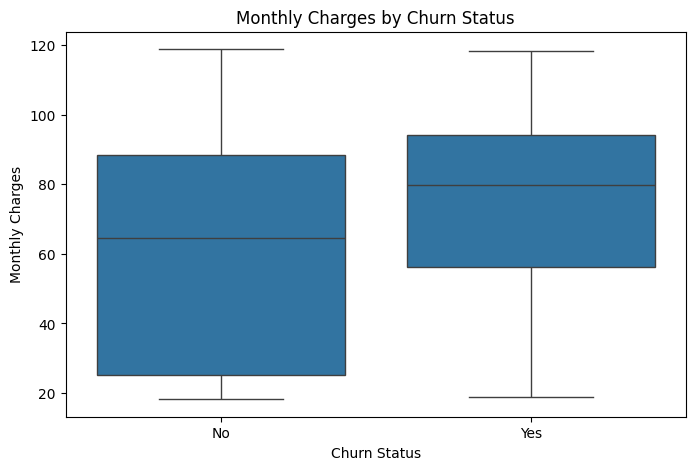

In [121]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=telco_clean,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")

plt.show()

#### Monthly Charges × Contract :

In [122]:
pd.crosstab(
    telco_clean["MonthlyChargeGroup"],
    telco_clean["Contract"],
    normalize="index"
).round(3)

Contract,Month-to-month,One year,Two year
MonthlyChargeGroup,,,
Q1 - Lowest,0.410,0.224,0.366
Q2,0.628,0.210,0.162
Q3,0.668,0.149,0.183
Q4 - Highest,0.495,0.254,0.251


In [123]:
monthly_contract_churn = (
    telco_clean
    .groupby(
        ["MonthlyChargeGroup", "Contract"],
        observed=True
    )["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

monthly_contract_churn.round(2)

,MonthlyChargeGroup,Contract,ChurnRate
0,Q1 - Lowest,Month-to-month,25.03
1,Q1 - Lowest,One year,3.05
2,Q1 - Lowest,Two year,0.78
3,Q2,Month-to-month,35.62
4,Q2,One year,8.63
5,Q2,Two year,2.45
6,Q3,Month-to-month,53.28
7,Q3,One year,11.07
8,Q3,Two year,1.55
9,Q4 - Highest,Month-to-month,52.18


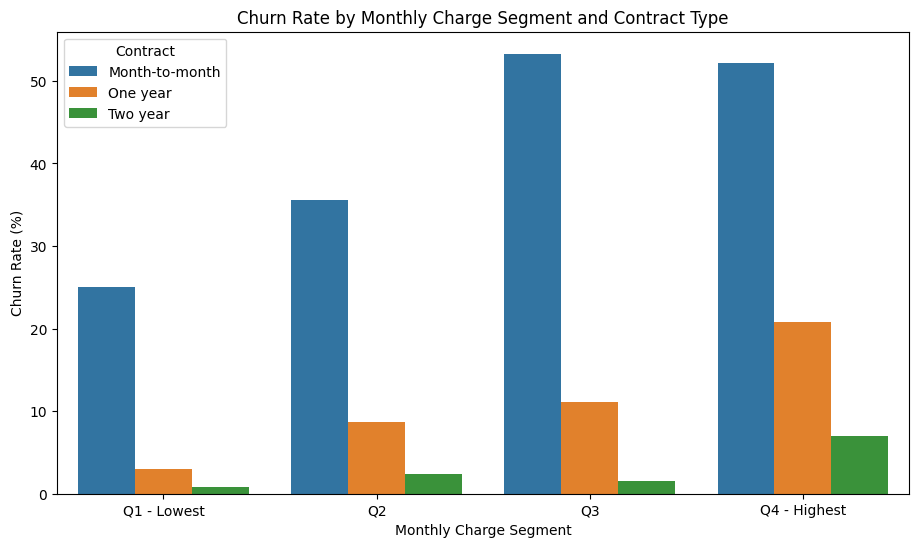

In [124]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=monthly_contract_churn,
    x="MonthlyChargeGroup",
    y="ChurnRate",
    hue="Contract"
)

plt.title("Churn Rate by Monthly Charge Segment and Contract Type")
plt.xlabel("Monthly Charge Segment")
plt.ylabel("Churn Rate (%)")

plt.show()

#### Observation :

Customers who churned had higher average and median monthly charges than customers who remained, indicating an observed association between monthly charges and churn.

However, the distributions show substantial overlap between churned and retained customers, indicating that MonthlyCharges alone is not sufficient to clearly separate the two groups.

When customers were segmented by monthly charge quartiles, the highest-charge group (Q4) did not have the highest overall churn rate. Further analysis showed that Q3 contained a much larger proportion of month-to-month customers (66.8%) compared with Q4 (49.5%), while Q4 had a greater proportion of one-year and two-year customers.

Since contract type is strongly associated with churn, differences in contract composition help explain why the aggregate churn rate of Q4 is lower than Q3 despite higher monthly charges.

This demonstrates that the relationship between MonthlyCharges and churn is influenced by other customer characteristics and should therefore be interpreted in a multivariate context. 

In [125]:
total_charge_summary = (
    telco_clean
    .groupby("Churn")["TotalCharges"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

total_charge_summary.round(2)

,count,mean,median,std,min,max
Churn,,,,,,
No,5174,2549.91,1679.52,2329.95,0.00,8672.45
Yes,1869,1531.80,703.55,1890.82,18.85,8684.80


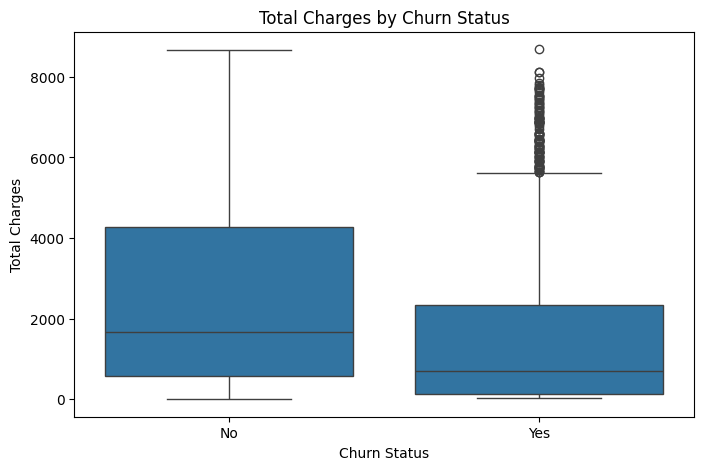

In [126]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=telco_clean,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Total Charges")

plt.show()

#### TotalCharges × Tenure :

In [127]:
telco_clean[["tenure", "MonthlyCharges", "TotalCharges"]].corr().round(3)

,tenure,MonthlyCharges,TotalCharges
tenure,1.000,0.248,0.826
MonthlyCharges,0.248,1.000,0.651
TotalCharges,0.826,0.651,1.000


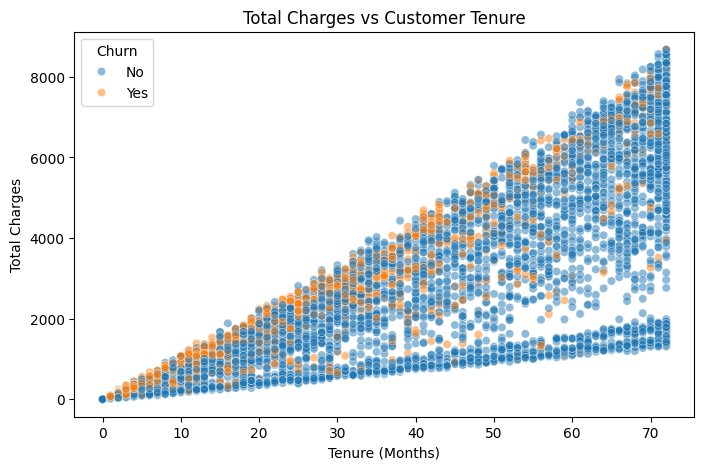

In [128]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=telco_clean,
    x="tenure",
    y="TotalCharges",
    hue="Churn",
    alpha=0.5
)

plt.title("Total Charges vs Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Total Charges")

plt.show()

#### Observation :

TotalCharges shows a strong positive correlation with Tenure (r = 0.826), while its correlation with MonthlyCharges is moderate-to-strong (r = 0.651).

The scatter plot confirms a strong increasing relationship between customer tenure and accumulated total charges. This is expected because customers who remain with the company for longer periods generally accumulate higher charges.

Churned customers are more concentrated in the lower-tenure and lower-TotalCharges region. However, the lower TotalCharges observed among churned customers should not be interpreted as a direct causal factor for churn, since TotalCharges is strongly associated with Tenure, which itself has a strong relationship with churn.

Therefore, TotalCharges contains useful information but also overlaps substantially with Tenure. This potential multicollinearity will be considered during the feature-selection and modelling stages rather than removing the feature at the EDA stage. 

### EDA - Remaining Categorical Features :

#### Gender :

In [129]:
gender_analysis = churn_analysis(telco_clean, "gender")
gender_analysis

,CustomerCount,ChurnRate
gender,,
Female,3488,26.920872
Male,3555,26.160338


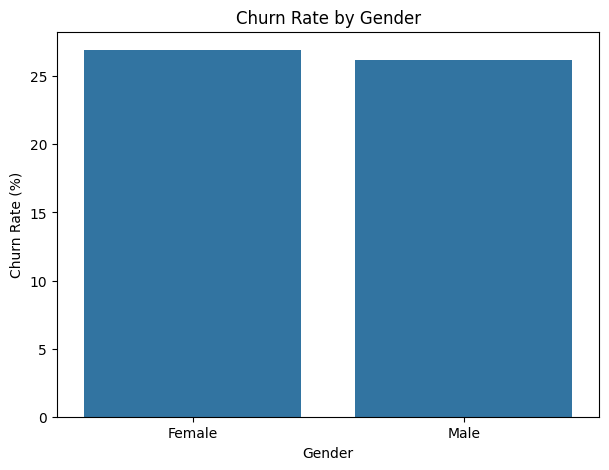

In [130]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=gender_analysis,
    x="gender",
    y="ChurnRate"
)

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")

plt.show()

#### Observation :

Female customers have a churn rate of 26.92%, while male customers have a churn rate of 26.16%. The difference is only 0.76 percentage points, indicating very little difference in observed churn rates between the two groups.

Therefore, Gender does not appear to be a practically important churn driver in this dataset based on univariate analysis. However, the feature will not be removed solely on this observation, as its potential contribution in combination with other variables will be evaluated during modelling and feature selection. 

### 5. Final EDA Findings :

#### Strong observed associations with churn :

- **Contract:** Month-to-month customers show substantially higher churn than one-year and two-year customers.
- **Tenure:** Customers with shorter tenure have considerably higher churn rates.
- **InternetService:** Fiber-optic customers show higher churn than DSL customers, while customers without internet service have the lowest churn.
- **OnlineSecurity:** Customers without online security have substantially higher churn than customers with the service.
- **TechSupport:** Customers without technical support show substantially higher churn.
- **PaymentMethod:** Electronic check customers have notably higher churn than other payment methods.
- **MonthlyCharges:** Churned customers have higher average and median monthly charges.

#### Moderate or context-dependent associations :

- **SeniorCitizen:** Senior customers show higher observed churn, although they represent a smaller portion of the dataset.
- **Partner:** Customers without a partner show higher churn.
- **Dependents:** Customers without dependents show higher churn.
- **PaperlessBilling:** Customers using paperless billing show higher churn.
- **TotalCharges:** Churned customers have lower total charges, but this relationship overlaps strongly with tenure.
- **DeviceProtection / OnlineBackup:** Customers without these services generally show higher churn.

#### Weak observed associations :

- **Gender:** Churn rates are very similar between male and female customers.
- **PhoneService:** Churn rates are very similar between customers with and without phone service.
- **MultipleLines:** Churn rates are relatively similar across the categories.
- **StreamingTV / StreamingMovies:** These features show relatively small differences compared with stronger churn-related features.

### Important EDA conclusions

The analysis indicates that churn is not driven by a single feature. Customer tenure, contract type, pricing, internet service, payment method, and additional services show stronger observed associations with churn.

Several features also interact with one another. For example, the relationship between MonthlyCharges and churn changes when customers are segmented by Contract. Similarly, TotalCharges is strongly correlated with Tenure, indicating overlapping information.

These findings will guide feature engineering and model development. However, observed associations from EDA should not be interpreted as causal relationships.

# 3. Feature Engineering :

### 3.1 Seperating our Feature groups :

In [131]:
categorical_cols = telco_clean.select_dtypes(
    include="object"
).columns.tolist()

numerical_cols = telco_clean.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_cols, numerical_cols

(['customerID',
  'gender',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod',
  'Churn'],
 ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'])

### 3.2 Defining X and y :

In [132]:
X = telco_clean.drop(
    columns=["customerID", "Churn"]
)
y = telco_clean["Churn"]

X.shape,y.shape

((7043, 21), (7043,))

In [133]:
telco_clean.shape

(7043, 23)

### 3.3 Removing EDA-Only Features :

In [134]:
X_model = X.drop(
    columns=["TenureGroup", "MonthlyChargeGroup"]
)

print("Model features:", X_model.shape[1])
print("Shape:", X_model.shape)

Model features: 19
Shape: (7043, 19)


#### Observation :

The EDA-specific features `TenureGroup` and `MonthlyChargeGroup` were removed from the modelling dataset because they are derived categorical representations of the original numerical variables `tenure` and `MonthlyCharges`.

The original numerical variables retain more detailed information and allow machine learning models to learn relationships without imposing arbitrary bins.

### 3.4 Creating a Service Count Feature :

#### 3.4.1 Identifying Service Features :

The following variables represent additional services used by customers:

- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport
- StreamingTV
- StreamingMovies

These binary service variables will be combined to create a `ServiceCount` feature representing the total number of additional services used by each customer.

In [135]:
service_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

#### 3.4.2 Convert Service Usage into a Count :

In [136]:
X_model["ServiceCount"] = (
    X_model[service_cols]
    .eq("Yes")
    .sum(axis=1)
)

#### 3.4.3 Check the New Feature :

In [137]:
X_model["ServiceCount"].value_counts().sort_index()

ServiceCount
0    2219
1     966
2    1033
3    1118
4     852
5     571
6     284
Name: count, dtype: int64

In [138]:
X_model["ServiceCount"].describe()

count    7043.000000
mean        2.037910
std         1.847682
min         0.000000
25%         0.000000
50%         2.000000
75%         3.000000
max         6.000000
Name: ServiceCount, dtype: float64

In [139]:
X_model.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,ServiceCount
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,2
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,2
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,3
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,0


#### 3.2.5 Analysing Whether ServiceCount Is Actually Useful :

In [140]:
service_count_churn = (
    pd.DataFrame({
        "ServiceCount": X_model["ServiceCount"],
        "Churn": y
    })
    .groupby("ServiceCount")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

service_count_churn.round(2)

ServiceCount
0    21.41
1    45.76
2    35.82
3    27.37
4    22.30
5    12.43
6     5.28
Name: Churn, dtype: float64

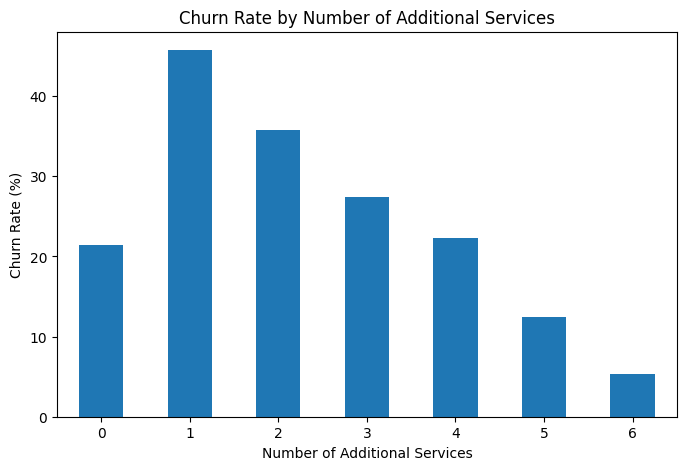

In [141]:
plt.figure(figsize=(8, 5))

service_count_churn.plot(kind="bar")

plt.title("Churn Rate by Number of Additional Services")
plt.xlabel("Number of Additional Services")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)

plt.show()

In [142]:
service_count_summary = (
    pd.DataFrame({
        "ServiceCount": X_model["ServiceCount"],
        "Churn": y
    })
    .groupby("ServiceCount")
    .agg(
        CustomerCount=("Churn", "size"),
        ChurnRate=("Churn", lambda x: (x == "Yes").mean() * 100)
    )
)

service_count_summary.round(2)

,CustomerCount,ChurnRate
ServiceCount,,
0,2219,21.41
1,966,45.76
2,1033,35.82
3,1118,27.37
4,852,22.30
5,571,12.43
6,284,5.28


#### Preliminary Observation :

ServiceCount shows a strong overall association with churn. Customers with higher numbers of additional services generally exhibit lower churn rates, particularly among customers using five or six services.

However, the relationship is not perfectly monotonic, with customers using exactly one additional service showing an unusually high churn rate. Customer counts for each ServiceCount category will therefore be examined before deciding how useful this engineered feature is for modelling.

#### Final Observation :

ServiceCount shows a strong observed association with churn. From one to six additional services, churn decreases substantially, from 45.76% to 5.28%. Customers using five or six additional services show particularly low churn rates.

Customers with exactly one additional service have the highest observed churn rate at 45.76%, indicating that the relationship is not perfectly monotonic across all categories.

The engineered feature is retained as a candidate model feature because it captures overall breadth of service adoption. However, it overlaps with the individual service variables from which it was created. Its incremental predictive value will therefore be evaluated during model development rather than assumed from EDA alone.

### 3.5 Creating a New Customer Indicator :

Earlier EDA showed that customers with very short tenure have substantially higher churn rates.

To represent this business segment explicitly, we create `IsNewCustomer`, where customers with six months or less of tenure are classified as new customers.

This feature is intended to capture the early-customer retention segment in a simple, interpretable form.

In [143]:
X_model["IsNewCustomer"] = (
    X_model["tenure"] <= 6
).astype(int)

In [144]:
X_model["IsNewCustomer"].value_counts()

IsNewCustomer
0    5562
1    1481
Name: count, dtype: int64

In [145]:
new_customer_churn = (
    pd.DataFrame({
        "IsNewCustomer": X_model["IsNewCustomer"],
        "Churn": y
    })
    .groupby("IsNewCustomer")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

new_customer_churn.round(2)

IsNewCustomer
0    19.51
1    52.94
Name: Churn, dtype: float64

# 4. Model Preperation :

### 4.1 Train-Test Split : 

#### 4.1.2 - Checking the target distribution first :

In [146]:
y.value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [147]:
y.value_counts(normalize=True).mul(100).round(2)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

#### 4.1.3 - Split the data :

In [148]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [149]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

X_train: (5634, 21)
X_test : (1409, 21)
y_train: (5634,)
y_test : (1409,)

Training target distribution:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

Testing target distribution:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [150]:
X_train.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'ServiceCount', 'IsNewCustomer'],
      dtype='object')

### 4.2 - Preprocessing pipeline  :

#### 4.2.1 - Seperating Features :

In [151]:
numeric_features = X_train.select_dtypes(
    include="number"
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'ServiceCount', 'IsNewCustomer']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [152]:
X_model.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,ServiceCount,IsNewCustomer
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,1,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,2,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,2,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,3,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,0,1


#### 4.2.2 Building the Preprocessing Pipeline :

A ColumnTransformer is used to apply different preprocessing techniques according to feature type. Numerical features are standardized using StandardScaler, while categorical features are converted into numerical representations using OneHotEncoder.

The encoder uses `handle_unknown="ignore"` to safely handle categories that may appear in unseen data, while `drop="first"` removes one reference category to reduce redundant encoded features.

The preprocessing pipeline is defined before fitting so that it can later be fitted exclusively on the training data and applied consistently to both training and test datasets.

In [153]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

#### 4.2.3 - Fit & Transform the Data :

In [154]:
preprocessor.fit(X_train)

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [155]:
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Original X_train shape:", X_train.shape)
print("Processed X_train shape:", X_train_processed.shape)

print("Original X_test shape:", X_test.shape)
print("Processed X_test shape:", X_test_processed.shape)

Original X_train shape: (5634, 21)
Processed X_train shape: (5634, 32)
Original X_test shape: (1409, 21)
Processed X_test shape: (1409, 32)


In [156]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))

Number of processed features: 32


In [157]:
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_train_processed_df.head()

,num__SeniorCitizen,num__tenure,num__MonthlyCharges,num__TotalCharges,num__ServiceCount,num__IsNewCustomer,cat__gender_Male,cat__Partner_Yes,cat__Dependents_Yes,cat__PhoneService_Yes,...,cat__StreamingTV_No internet service,cat__StreamingTV_Yes,cat__StreamingMovies_No internet service,cat__StreamingMovies_Yes,cat__Contract_One year,cat__Contract_Two year,cat__PaperlessBilling_Yes,cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check
3738,-0.441773,0.102371,-0.521976,-0.262257,0.507935,-0.511954,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3151,-0.441773,-0.711743,0.337478,-0.503635,-0.570530,-0.511954,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4860,-0.441773,-0.793155,-0.809013,-0.749883,0.507935,-0.511954,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3867,-0.441773,-0.263980,0.284384,-0.172722,1.047168,-0.511954,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0
3810,-0.441773,-1.281624,-0.676279,-0.989374,-1.109762,1.953301,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


The preprocessing pipeline is fitted exclusively on the training data to prevent data leakage. During fitting, StandardScaler learns the scaling parameters for numerical features, while OneHotEncoder learns the available categories for categorical features.

The learned preprocessing rules are then applied to both the training and testing datasets. The training data is fitted and transformed, whereas the testing data is transformed using the parameters learned from the training data only.

One-hot encoding expands the original feature space because categorical variables with multiple categories are represented using multiple binary features.

### 4.3 - Baseline model - Logistic Regression :

Logistic Regression is selected as the first baseline model because the project is a binary classification problem where the target represents whether a customer churns or not.

The categorical target values are encoded as 0 and 1, where 0 represents no churn and 1 represents churn.

The model is trained using the preprocessed training data and then evaluated on the unseen test data. Both class predictions and churn probabilities are generated. Probabilities will later be useful for threshold analysis and customer risk prioritization.

#### 4.3.1 - Convert the target :

In [158]:
y_train_encoded = y_train.map({
    "No": 0,
    "Yes": 1
})

y_test_encoded = y_test.map({
    "No": 0,
    "Yes": 1
})

y_train_encoded.value_counts()

Churn
0    4139
1    1495
Name: count, dtype: int64

#### 4.3.2 Baseline Model Building ,Training & Testing :

In [159]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [160]:
logistic_model.fit(
    X_train_processed,
    y_train_encoded
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [161]:
y_pred = logistic_model.predict(X_test_processed)

In [162]:
y_pred_proba = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

### 4.4 - Baseline Model Evaluation :

In [182]:
def evaluate_model(model, X_test, y_test):
    
    y_pred = model.predict(X_test)
    
    y_prob = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC-AUC   : {roc_auc:.4f}")
    print("\nConfusion Matrix:")
    print(cm)

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }

logistic_results = evaluate_model(logistic_model,X_test_processed,y_test_encoded)

Accuracy  : 0.8041
Precision : 0.6644
Recall    : 0.5294
F1 Score  : 0.5893
ROC-AUC   : 0.8460

Confusion Matrix:
[[935 100]
 [176 198]]


### 4.5 - ROC Curve & Threshold Analysis :

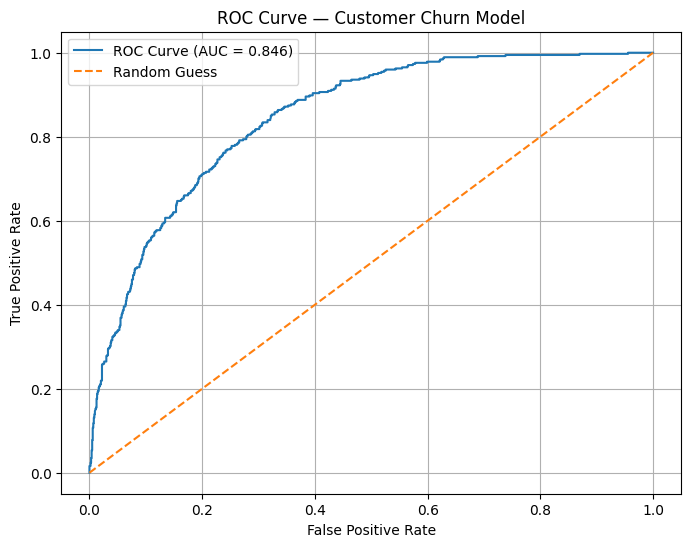

In [165]:
fpr, tpr, thresholds = roc_curve(
    y_test_encoded,
    y_pred_proba
)

roc_auc = roc_auc_score(
    y_test_encoded,
    y_pred_proba
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC Curve (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Customer Churn Model")

plt.legend()
plt.grid(True)

plt.show()

In [166]:
threshold_analysis = pd.DataFrame({
    "Threshold": thresholds,
    "TPR_Recall": tpr,
    "FPR": fpr
})

threshold_analysis.head(10)

,Threshold,TPR_Recall,FPR
0,inf,0.000000,0.000000
1,0.903682,0.002674,0.000000
2,0.869729,0.016043,0.000000
3,0.867553,0.016043,0.001932
4,0.856770,0.024064,0.001932
5,0.853209,0.024064,0.002899
6,0.845775,0.034759,0.002899
7,0.839509,0.034759,0.003865
8,0.819548,0.053476,0.003865
9,0.818029,0.053476,0.004831


In [186]:
results = []

for threshold in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:

    predictions = (
        y_pred_proba >= threshold
    ).astype(int)

    results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test_encoded,
            predictions
        ),
        "Recall": recall_score(
            y_test_encoded,
            predictions
        ),
        "F1 Score": f1_score(
            y_test_encoded,
            predictions
        )
    })

threshold_results = pd.DataFrame(results)

threshold_results.round(3)

,Threshold,Precision,Recall,F1 Score
0,0.30,0.533,0.762,0.627
1,0.35,0.560,0.711,0.627
2,0.40,0.580,0.660,0.618
3,0.45,0.614,0.607,0.610
4,0.50,0.664,0.529,0.589
5,0.55,0.687,0.457,0.549
6,0.60,0.702,0.385,0.497


#### Observation - ROC Curve and Threshold Analysis :

The Logistic Regression model achieved a ROC-AUC score of 0.846, indicating a strong ability to distinguish between customers who churn and those who do not. At the default classification threshold of 0.50, the model achieved a precision of 66.44%, recall of 52.94%, and F1-score of 58.93%.

Threshold analysis showed that lowering the threshold increases the model's ability to identify actual churners. For example, reducing the threshold from 0.50 to 0.30 increased recall from 52.94% to 76.2% and improved the F1-score to 62.7%, while precision decreased from 66.44% to 53.3%.

This demonstrates the trade-off between precision and recall. Since the objective of the project is customer churn prevention, recall is particularly important because failing to identify an actual churner may result in a missed retention opportunity. However, the final classification threshold should be selected based on the business cost associated with false positives and false negatives.

### 4.6 - Model Comparision :

In [187]:
model_results = []

model_results.append({
    "Model": "Logistic Regression",
    **logistic_results
})

pd.DataFrame(model_results)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.804116,0.66443,0.529412,0.589286,0.845984


### 4.7 - Decision Tree :

In [188]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(
    X_train_processed,
    y_train_encoded
)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [189]:
decision_tree_results = evaluate_model(
    decision_tree,
    X_test_processed,
    y_test_encoded
)

Accuracy  : 0.7303
Precision : 0.4915
Recall    : 0.4652
F1 Score  : 0.4780
ROC-AUC   : 0.6451

Confusion Matrix:
[[855 180]
 [200 174]]


In [190]:
model_results.append({
    "Model": "Decision Tree",
    **decision_tree_results
})
pd.DataFrame(model_results)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.804116,0.664430,0.529412,0.589286,0.845984
1,Decision Tree,0.730305,0.491525,0.465241,0.478022,0.645147


### 4.8 - Random Forest :

In [193]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(
    X_train_processed,
    y_train_encoded
)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [194]:
random_forest_results = evaluate_model(
    random_forest,
    X_test_processed,
    y_test_encoded
)

Accuracy  : 0.7906
Precision : 0.6376
Recall    : 0.4893
F1 Score  : 0.5537
ROC-AUC   : 0.8227

Confusion Matrix:
[[931 104]
 [191 183]]


In [195]:
model_results.append({
    "Model": "Random Forest",
    **random_forest_results
})

pd.DataFrame(model_results)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.804116,0.664430,0.529412,0.589286,0.845984
1,Decision Tree,0.730305,0.491525,0.465241,0.478022,0.645147
2,Random Forest,0.790632,0.637631,0.489305,0.553707,0.822676


### 4.9 - XGBoost :

In [197]:
print(xgb.__version__)

3.2.0


In [198]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train_processed,
    y_train_encoded
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [199]:
xgb_results = evaluate_model(
    xgb_model,
    X_test_processed,
    y_test_encoded
)

Accuracy  : 0.7999
Precision : 0.6503
Recall    : 0.5321
F1 Score  : 0.5853
ROC-AUC   : 0.8431

Confusion Matrix:
[[928 107]
 [175 199]]


In [200]:
model_results.append({
    "Model": "XGBoost",
    **xgb_results
})
pd.DataFrame(model_results)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.804116,0.664430,0.529412,0.589286,0.845984
1,Decision Tree,0.730305,0.491525,0.465241,0.478022,0.645147
2,Random Forest,0.790632,0.637631,0.489305,0.553707,0.822676
3,XGBoost,0.799858,0.650327,0.532086,0.585294,0.843105


#### 4.10 - Model Comparision Chart :

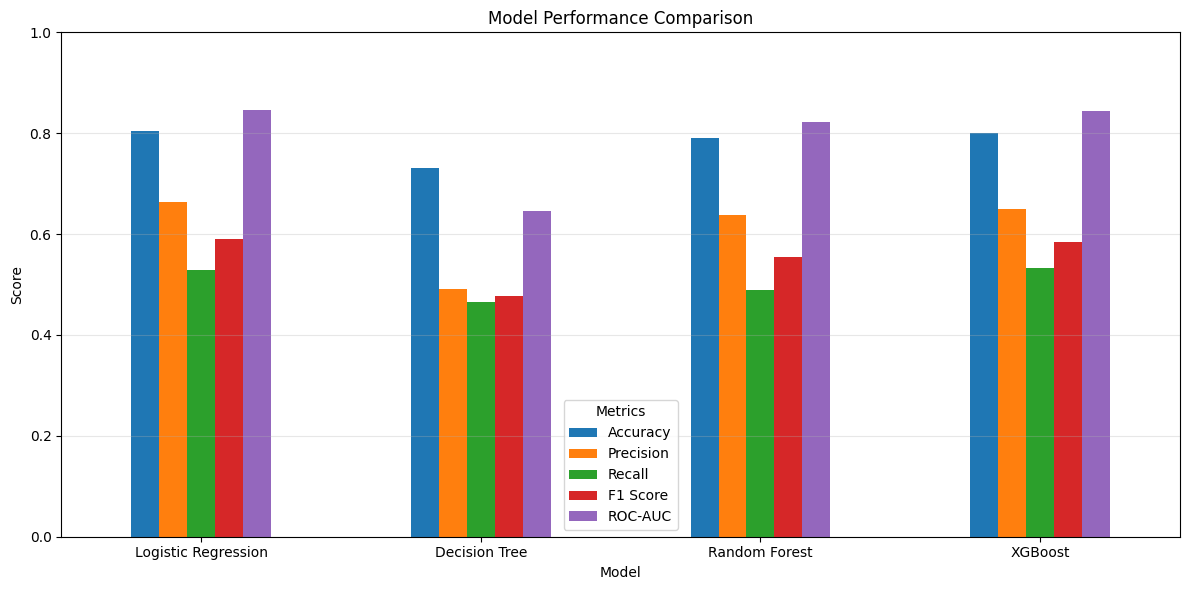

In [217]:
comparison = pd.DataFrame(model_results)

metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

comparison_plot = comparison.set_index("Model")[metrics]

comparison_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title="Metrics")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

#### Observation:

- Logistic Regression achieved the highest overall performance among the four evaluated models, with the highest accuracy (80.41%), precision (66.44%), F1-score (58.93%), and ROC-AUC (84.60%).
- XGBoost showed a slightly higher recall (53.21%) than Logistic Regression (52.94%), but its overall ROC-AUC (84.31%) and F1-score (58.53%) were slightly lower.
- Random Forest performed reasonably well but remained below Logistic Regression across the major evaluation metrics.
- Decision Tree produced the weakest overall performance, with lower accuracy, precision, recall, F1-score, and ROC-AUC.
- Since ROC-AUC measures the model's ability to distinguish between churners and non-churners across different classification thresholds, Logistic Regression's highest ROC-AUC makes it the strongest overall candidate.
- Logistic Regression also provides a good balance between performance, simplicity, interpretability, and computational efficiency.
- Therefore, Logistic Regression was selected as the best candidate for further hyperparameter tuning and threshold optimization.

# 5. Hyperparameter Tuning - Logistic Regression :

#### 5.1 Cross Validation :

In [204]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"],
    "class_weight": [None, "balanced"]
}

In [206]:
logistic_tuning = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

logistic_tuning.fit(
    X_train_processed,
    y_train_encoded
)

,estimator,LogisticRegre...max_iter=1000)
,param_grid,"{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced'], 'solver': ['liblinear', 'lbfgs']}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [207]:
print("Best Parameters:")
print(logistic_tuning.best_params_)

print("\nBest CV ROC-AUC:")
print(logistic_tuning.best_score_)

Best Parameters:
{'C': 100, 'class_weight': None, 'solver': 'liblinear'}

Best CV ROC-AUC:
0.8486596177578456


In [208]:
tuned_logistic_results = evaluate_model(
    logistic_tuning.best_estimator_,
    X_test_processed,
    y_test_encoded
)

Accuracy  : 0.7984
Precision : 0.6500
Recall    : 0.5214
F1 Score  : 0.5786
ROC-AUC   : 0.8443

Confusion Matrix:
[[930 105]
 [179 195]]


##### The original Logistic Regression remains better than the tuned Logistic Regression on the test set.

#### 5.2 - Final Threshold Optimization :

In [209]:
y_prob_logistic = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

threshold_results = []

for threshold in np.arange(0.20, 0.61, 0.05):

    y_pred_threshold = (
        y_prob_logistic >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test_encoded,
            y_pred_threshold
        ),
        "Recall": recall_score(
            y_test_encoded,
            y_pred_threshold
        ),
        "F1 Score": f1_score(
            y_test_encoded,
            y_pred_threshold
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.round(3)

,Threshold,Precision,Recall,F1 Score
0,0.20,0.476,0.866,0.615
1,0.25,0.501,0.816,0.621
2,0.30,0.533,0.762,0.627
3,0.35,0.560,0.711,0.627
4,0.40,0.580,0.660,0.618
5,0.45,0.614,0.607,0.610
6,0.50,0.664,0.529,0.589
7,0.55,0.687,0.457,0.549
8,0.60,0.702,0.385,0.497


#### 5.3 - Final Threshold Evaluation :

In [210]:
threshold = 0.30

y_pred_30 = (y_prob_logistic >= threshold).astype(int)

In [211]:
cm_30 = confusion_matrix(y_test_encoded, y_pred_30)

print("Confusion Matrix at Threshold 0.30:")
print(cm_30)

Confusion Matrix at Threshold 0.30:
[[785 250]
 [ 89 285]]


In [212]:
print("Precision :", precision_score(y_test_encoded, y_pred_30))
print("Recall    :", recall_score(y_test_encoded, y_pred_30))
print("F1 Score  :", f1_score(y_test_encoded, y_pred_30))

Precision : 0.5327102803738317
Recall    : 0.7620320855614974
F1 Score  : 0.6270627062706271


#### Observation:

- At the default threshold of 0.50, the Logistic Regression model achieved a recall of approximately 52.9%.
- Lowering the classification threshold to 0.30 increased recall substantially to 76.2%, meaning the model can identify around 3 out of every 4 customers who actually churn.
- At this threshold, the model correctly identified 285 out of 374 actual churners, while 89 churners were missed.
- The precision decreased to 53.3%, indicating that some customers predicted as churners will not actually churn.
- The F1-score improved from 58.9% at the default threshold to 62.7% at the 0.30 threshold.
- Since the primary business objective is to identify potential churners early and support customer-retention actions, a threshold of 0.30 was selected instead of the default 0.50.
- This threshold prioritizes higher recall while maintaining a reasonable balance between precision and recall. 

#### 5.4 - Final Model :

In [213]:
final_model = logistic_model
final_threshold = 0.30

print("Final Model:", final_model)
print("Final Threshold:", final_threshold)

Final Model: LogisticRegression(max_iter=1000, random_state=42)
Final Threshold: 0.3


In [214]:
final_probabilities = final_model.predict_proba(
    X_test_processed
)[:, 1]

final_predictions = (
    final_probabilities >= final_threshold
).astype(int)

final_accuracy = accuracy_score(
    y_test_encoded,
    final_predictions
)

final_precision = precision_score(
    y_test_encoded,
    final_predictions
)

final_recall = recall_score(
    y_test_encoded,
    final_predictions
)

final_f1 = f1_score(
    y_test_encoded,
    final_predictions
)

final_roc_auc = roc_auc_score(
    y_test_encoded,
    final_probabilities
)

print("Final Model Performance")
print("-----------------------")
print(f"Accuracy  : {final_accuracy:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1 Score  : {final_f1:.4f}")
print(f"ROC-AUC   : {final_roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_encoded, final_predictions))

Final Model Performance
-----------------------
Accuracy  : 0.7594
Precision : 0.5327
Recall    : 0.7620
F1 Score  : 0.6271
ROC-AUC   : 0.8460

Confusion Matrix:
[[785 250]
 [ 89 285]]


#### Observation:

- Logistic Regression was selected as the final model because it achieved the strongest overall performance among the evaluated models, particularly in terms of ROC-AUC and precision.
- Hyperparameter tuning did not improve the model's performance on the unseen test set, so the original Logistic Regression model was retained.
- The default classification threshold of 0.50 was replaced with a threshold of 0.30 to prioritize churn detection.
- At the 0.30 threshold, the model achieved approximately 76.2% recall and 62.7% F1-score.
- The lower threshold increases the number of customers identified as potential churners, resulting in more false positives but significantly reducing missed churners.
- This threshold was selected based on the business objective of identifying potential churners early so that retention strategies can be applied.
- The final model therefore prioritizes customer-churn detection rather than maximizing accuracy alone.

#### 5.5 - Final Model Summary :

In [215]:
final_summary = pd.DataFrame([{
    "Model": "Logistic Regression",
    "Threshold": final_threshold,
    "Accuracy": final_accuracy,
    "Precision": final_precision,
    "Recall": final_recall,
    "F1 Score": final_f1,
    "ROC-AUC": final_roc_auc
}])

final_summary.round(4)

,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.3,0.7594,0.5327,0.762,0.6271,0.846


#### 5.6 - Final Business Interpretation :

#### Business Interpretation:

The final Customer Churn Prediction model identifies customers who are at higher risk of leaving the company. Instead of relying on the default 0.50 classification threshold, a threshold of 0.30 was selected to improve churn detection.

With this threshold, the model identifies approximately 76% of actual churners. Although this produces additional false positives, it allows the company to identify a larger proportion of customers who may require retention attention.

The model can therefore be used as a customer-retention support tool, helping the business prioritize high-risk customers for targeted offers, customer support, loyalty programs, or other retention strategies.

# 6. Model Deployement :

In [216]:
import joblib

joblib.dump(
    final_model,
    "customer_churn_logistic_model.pkl"
)

joblib.dump(
    preprocessor,
    "customer_churn_preprocessor.pkl"
)

print("Final model and preprocessor saved successfully.")

Final model and preprocessor saved successfully.


In [8]:
import sys
import numpy
import pandas
import matplotlib
import seaborn
import sklearn
import joblib
import xgboost

print("Python     :", sys.version)
print("NumPy      :", numpy.__version__)
print("Pandas     :", pandas.__version__)
print("Matplotlib :", matplotlib.__version__)
print("Seaborn    :", seaborn.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Joblib     :", joblib.__version__)
print("XGBoost    :", xgboost.__version__)

Python     : 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
NumPy      : 1.26.4
Pandas     : 2.3.3
Matplotlib : 3.10.8
Seaborn    : 0.13.2
Scikit-learn: 1.7.2
Joblib     : 1.5.3
XGBoost    : 3.2.0


## Alhamduillah !!! The End !!!